[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/01_eda.ipynb)

# 01 — Exploratory Data Analysis

**Purpose.** Understand what `00_simulation.ipynb` produced well enough to specify
notebook 02: what the columns mean, how they are distributed, where they are
missing, how records are grouped, and which values are impossible.

**Inputs.** The four simulation artifacts at the paths in `cfg.simulation.output`
— read-only, never modified.

**Outputs.** *Insights, not artifacts.* Nothing here writes to `data/` or
`models/`. The deliverable is section 10: a written specification of what
notebook 02 must do.

**Rules.**
- The artifacts are never modified. Regenerate them with `task simulation`.
- Findings here are hypotheses. Any threshold *derived* from this data is a
  statistical threshold and belongs in a `02x` notebook, fitted on train only.
- A bound is only allowed in notebook 02 if you can name its external source
  (a standard, a specification, a physical limit). Record candidates in
  section 10 together with that source.

## 0. Environment

Run this section first, wherever you are.

**Locally** it only walks up to the project root and makes it the working
directory, so the root-relative paths in `configs/simulation.yaml` resolve the
same way they do for `task simulation`. Nothing is installed.

**In Colab** it also clones the repository, puts it on `sys.path` so `import src`
works without an editable install, and installs the packages Colab does not
already ship. Note that `data/` is DVC-tracked and therefore *not* part of the
clone — see the Drive cell below.

In [1]:
# --- Environment bootstrap -------------------------------------------------
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
BRANCH = "main"
SUBDIR = "."  # project root inside the repository

# (import name, pip name). Colab already ships numpy, pandas, matplotlib and
# seaborn, so only these are installed. Sionna-RT is needed by section 2, which
# renders the scene; it needs a CUDA GPU runtime.
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    checkout = Path("/content") / Path(REPO_URL).stem
    if not checkout.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],
            check=True,
        )
    root = (checkout / SUBDIR).resolve()
    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    # JupyterLab starts the kernel in notebooks/; walk up to the project root.
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))  # makes `import src` work without an editable install

# Extra Hydra overrides consumed by load_config() in section 1.
CONFIG_OVERRIDES: list[str] = []

print(f"project root: {root}   colab: {IN_COLAB}")

project root: d:\Projects\band-tilt   colab: False


In [2]:
# --- Colab: the artifacts (optional) ---------------------------------------
# data/ is DVC-tracked, so it is not in the Git clone and a fresh Colab runtime
# has none of it. Either run 00_simulation.ipynb first, or mount Drive and point
# the config at a copy there — Drive also survives a runtime reset.
#
# from google.colab import drive
#
# drive.mount("/content/drive")
# DATA_ROOT = "/content/drive/MyDrive/band-tilt/data"
# CONFIG_OVERRIDES += [
#     f"simulation.output.ue_file={DATA_ROOT}/external/ue_positions.csv",
#     f"simulation.output.manifest_file={DATA_ROOT}/external/scenario.json",
#     f"simulation.output.radio_map_file={DATA_ROOT}/interim/radio_map.npz",
#     f"simulation.output.mdt_file={DATA_ROOT}/interim/mdt.csv",
# ]

## 1. Setup

Compose the config, seed everything, and import from `src/`. Every notebook
starts the same way so that a cell copied between notebooks behaves identically.

In [3]:
%load_ext autoreload
%autoreload 2

from functools import partial
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf

from src.config import load_config
from src.evaluation import maps
from src.kpi import capacity
from src.evaluation.export import save_table
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()

# Figures and tables land here so they can be read without rerunning the notebook;
# skipped on Colab.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/01_eda"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/01_eda"))

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

In [4]:
# Same top-down camera as 00_simulation. A square resolution frames the scene the
# same way whichever axis mitsuba measures the field of view on.
RENDER_FOV = 45.0
RENDER_RESOLUTION = (900, 900)
RENDER_SAMPLES = 128


def top_down_camera(bounds, centre=None, span=None, margin=1.08):
    """Build a camera above ``centre`` looking straight down.

    Args:
        bounds: Scene extent, used for the default framing and the ground height.
        centre: ``(x, y)`` to look at. Defaults to the centre of ``bounds``.
        span: Ground width to cover in metres. Defaults to the longer side.
        margin: Slack left around ``span``.
    """
    from sionna.rt import Camera

    if centre is None:
        centre = (0.5 * (bounds.min_x + bounds.max_x), 0.5 * (bounds.min_y + bounds.max_y))
    if span is None:
        span = max(bounds.width_m, bounds.depth_m)
    height = bounds.max_z + 0.5 * span * margin / math.tan(math.radians(0.5 * RENDER_FOV))
    return Camera(
        position=[float(centre[0]), float(centre[1]), float(height)],
        look_at=[float(centre[0]), float(centre[1]), float(bounds.min_z)],
    )


def render(scene, camera, title, name=None, **kwargs):
    """Render ``scene`` at the shared fidelity, title it, save it under ``name`` if given, and show it."""
    figure = scene.render(
        camera=camera,
        fov=RENDER_FOV,
        resolution=RENDER_RESOLUTION,
        num_samples=RENDER_SAMPLES,
        **kwargs,
    )
    figure.axes[0].set_title(title)
    figure.tight_layout()  # sionna lays the figure out before the title exists
    if name is not None:
        save_fig(figure, name)
    plt.show()

## 2. Load the Artifacts and the Scene

Read-only. If a file is missing, run `00_simulation.ipynb` or `task simulation`.

In [5]:
out = cfg.simulation.output

ue = pd.read_csv(out.ue_file)
manifest = json.loads(Path(out.manifest_file).read_text(encoding="utf-8"))
with np.load(out.radio_map_file, allow_pickle=False) as archive:
    radio = {key: archive[key] for key in archive.files}
mdt = pd.read_csv(out.mdt_file)

rsrp = radio["rsrp_dbm"]
sinr = radio["sinr_db"]
bands = [str(label) for label in radio["band_label"]]
tx_names = [str(name) for name in radio["tx_name"]]
n_rows, n_cols = int(radio["n_rows"]), int(radio["n_cols"])
tile_size = float(radio["tile_size_m"])
origin_x, origin_y = float(radio["origin_x"]), float(radio["origin_y"])
extent = [origin_x, origin_x + n_cols * tile_size, origin_y, origin_y + n_rows * tile_size]

position_columns = [column for column in mdt.columns if not column.startswith(("rsrp_", "sinr_"))]
measurement_columns = [column for column in mdt.columns if column.startswith("rsrp_")]
# SINR computed by mdt.py from each reported RSRP, same cell-band order.
sinr_columns = [column for column in mdt.columns if column.startswith("sinr_")]

with warnings.catch_warnings():
    # A tile no ray reached is all-NaN over the transmitters, and nanmax over one warns.
    warnings.simplefilter("ignore", RuntimeWarning)
    best_server = np.stack([np.nanmax(rsrp[index], axis=0) for index in range(len(bands))])

pd.DataFrame(
    [
        {"artifact": "ue_positions", "rows": len(ue), "columns": ue.shape[1]},
        {"artifact": "mdt", "rows": len(mdt), "columns": mdt.shape[1]},
        {"artifact": "radio_map", "rows": str(rsrp.shape), "columns": "[band, tx, row, col]"},
        {"artifact": "scenario", "rows": len(manifest), "columns": "manifest keys"},
    ]
)

,artifact,rows,columns
0,ue_positions,10066,8
1,mdt,8874,61
2,radio_map,"(3, 9, 61, 74)","[band, tx, row, col]"
3,scenario,7,manifest keys


In [6]:
# Serving cell-band, SINR and PRBs per report, from src/kpi/capacity.py and the
# placeholder kpi.capacity settings. RSRP and the solver's SINR are read from the
# clean map at each report's tile.
capacity_spec = capacity.CapacitySpec.from_config(cfg, bands, len(tx_names))
served = capacity.serve_intervals(rsrp, sinr, bands, mdt, cfg)
peak_prb = capacity.demand_prb(rsrp, sinr, bands, mdt, cfg)

band_names = np.array(bands + ["blocked"], dtype=object)
cell_names = np.array(tx_names + ["blocked"], dtype=object)
served["serving_band"] = band_names[served["band"].to_numpy()]
served["serving_cell"] = cell_names[served["tx"].to_numpy()]

ue_row = mdt["tile_row"].to_numpy()
ue_col = mdt["tile_col"].to_numpy()
values = mdt[measurement_columns].to_numpy()
# The reported RSRP at the serving cell-band the rule chose, not the strongest
# report; NaN where the report was blocked. Columns are tx-major, band-minor.
served_band = served["band"].to_numpy()
served_tx = served["tx"].to_numpy()
has_server = served_band >= 0
serving_rsrp = np.full(len(mdt), np.nan)
serving_rsrp[has_server] = values[
    np.flatnonzero(has_server), served_tx[has_server] * len(bands) + served_band[has_server]
]

pd.DataFrame(
    {
        "value": {
            "rsrp_threshold_dbm": capacity_spec.rsrp_threshold_dbm,
            "throughput_per_ue_bps": capacity_spec.throughput_per_ue_bps,
            "max_prb per cell-band, min": float(capacity_spec.max_prb.min()),
            "max_prb per cell-band, max": float(capacity_spec.max_prb.max()),
            "reports": len(served),
            "blocked reports": int((served["band"] < 0).sum()),
            "peak PRB demand, busiest tile": float(peak_prb.max()),
        }
    }
)

,value
rsrp_threshold_dbm,-1.200000e+02
throughput_per_ue_bps,2.000000e+07
"max_prb per cell-band, min",5.200000e+01
"max_prb per cell-band, max",2.160000e+02
reports,8.874000e+03
blocked reports,1.304000e+03
"peak PRB demand, busiest tile",1.270889e+04


In [7]:
cells = pd.json_normalize(OmegaConf.to_container(cfg.simulation.transmitters.cells, resolve=True))
hotspots = pd.DataFrame(manifest["density"]["hotspots"])

pd.DataFrame(
    {
        "value": {
            "scenario_id": manifest["scenario_id"],
            "seed": manifest["seed"],
            **manifest["grid"],
            "n_intervals": manifest["time"]["n_intervals"],
            "n_hotspots": len(hotspots),
            "n_cells": len(cells),
        }
    }
)

,value
scenario_id,scn_28d06a5bfb4c02e6
seed,42
launch_z,108.57
n_cols,74
n_rows,61
origin_x,-805.583679
origin_y,-688.600647
tile_size_m,20.0
n_intervals,672
n_hotspots,4


The scene below is the city **as delivered** — the same geometry the RSRP
values were solved on.

jitc_llvm_init(): LLVM API initialization failed ..


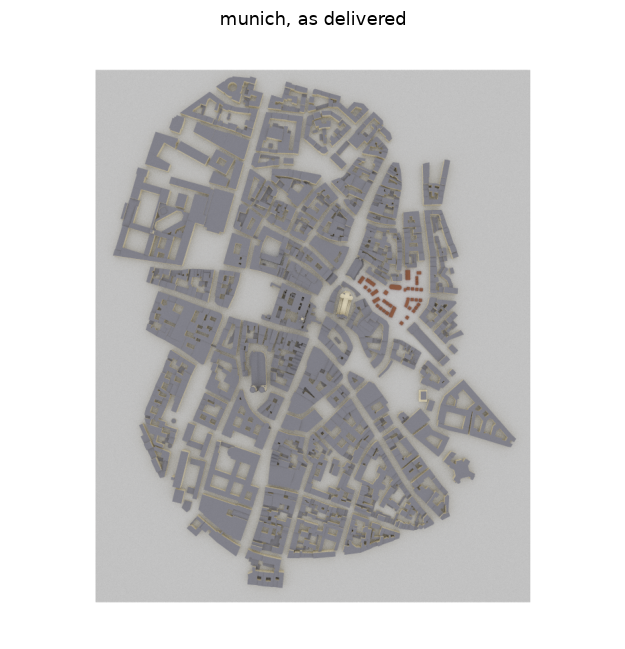

In [8]:
from src.simulation import scene as scene_module
from src.simulation.scene import SceneSpec

delivered_scene, delivered = scene_module.load(SceneSpec.from_config(cfg))
camera = top_down_camera(delivered)

render(
    delivered_scene, camera, f"{cfg.simulation.scene.name}, as delivered", name="scene_delivered"
)

In [9]:
# The measurement grid the radio map is solved on.
from src.simulation import grid as grid_module
from src.simulation import seeds
from src.simulation.grid import GridSpec

grid_spec = GridSpec.from_config(cfg)
raster = grid_module.build(
    delivered_scene.mi_scene, delivered, grid_spec, seeds.stream(cfg, "scene")
)
assert (raster.n_rows, raster.n_cols) == (n_rows, n_cols)

## 3. Schema — the Artifacts Against the Config

What is actually in the files, versus what `configs/simulation.yaml` declares.
Any gap found here is a change to the config, not a fix applied in code.

In [10]:
ue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10066 entries, 0 to 10065
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   t_index    10066 non-null  int64  
 1   t_s        10066 non-null  float64
 2   x          10066 non-null  float64
 3   y          10066 non-null  float64
 4   z          10066 non-null  float64
 5   tile_col   10066 non-null  int64  
 6   tile_row   10066 non-null  int64  
 7   component  10066 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 629.3 KB


In [11]:
print(f"mdt position columns  ({len(position_columns)}): {position_columns}")
print(f"mdt measurement columns ({len(measurement_columns)}): {measurement_columns[:4]} ...")
mdt.dtypes.value_counts().to_frame("columns")

mdt position columns  (7): ['t_index', 't_s', 'x', 'y', 'z', 'tile_col', 'tile_row']
mdt measurement columns (27): ['rsrp_n0c0_b2600', 'rsrp_n0c0_b1800', 'rsrp_n0c0_b700', 'rsrp_n0c1_b2600'] ...


,columns
float64,58
int64,3


In [12]:
pd.DataFrame(
    [
        {"key": key, "shape": str(value.shape), "dtype": str(value.dtype)}
        for key, value in radio.items()
    ]
)

,key,shape,dtype
0,rsrp_dbm,"(3, 9, 61, 74)",float32
1,sinr_db,"(3, 9, 61, 74)",float32
2,band_hz,"(3,)",float64
3,band_label,"(3,)",<U5
4,tilt_deg,"(3, 9)",float64
5,tx_name,"(9,)",<U4
6,origin_x,(),float64
7,origin_y,(),float64
8,tile_size_m,(),float64
9,n_cols,(),int64


In [13]:
configured_tx = [str(entry.name) for entry in cfg.simulation.transmitters.cells]
configured_bands = [str(entry.name) for entry in cfg.simulation.radio_map.bands]
# mdt.py names the measurement columns tx-major, band-minor.
expected_columns = [f"rsrp_{tx}_{band}" for tx in tx_names for band in bands]
grid_meta = manifest["grid"]

schema_checks = pd.DataFrame(
    [
        ("npz tx_name matches the configured cells", tx_names == configured_tx),
        ("npz band_label matches the configured bands", bands == configured_bands),
        ("mdt measurement columns are tx x band", measurement_columns == expected_columns),
        (
            "mdt sinr columns are tx x band",
            sinr_columns == [c.replace("rsrp_", "sinr_", 1) for c in expected_columns],
        ),
        (
            "npz scenario_id matches the manifest",
            str(radio["scenario_id"]) == manifest["scenario_id"],
        ),
        (
            "npz grid matches the manifest grid",
            (n_rows, n_cols, tile_size, origin_x, origin_y)
            == (
                grid_meta["n_rows"],
                grid_meta["n_cols"],
                grid_meta["tile_size_m"],
                grid_meta["origin_x"],
                grid_meta["origin_y"],
            ),
        ),
        (
            "npz ue_height_m matches the config",
            float(radio["ue_height_m"]) == float(cfg.simulation.ue.height_m),
        ),
        ("mdt is row-aligned with ue_positions", len(mdt) == len(ue)),
    ],
    columns=["check", "holds"],
)
save_table(schema_checks, "schema_checks")
schema_checks

,check,holds
0,npz tx_name matches the configured cells,True
1,npz band_label matches the configured bands,True
2,mdt measurement columns are tx x band,True
3,mdt sinr columns are tx x band,True
4,npz scenario_id matches the manifest,True
5,npz grid matches the manifest grid,True
6,npz ue_height_m matches the config,True
7,mdt is row-aligned with ue_positions,False


The last check fails by design: `mdt.build` drops UEs no transmitter reaches, so
the MDT is shorter than the UE table and the two cannot be joined by row order.
Section 4 quantifies the gap.

## 4. Missingness

- `rsrp_dbm` is NaN where the ray tracer found **no path**. That is a physical
  fact about the geometry, not a gap.
- An `rsrp_*` cell in the MDT is empty for the same reason and no other: every
  cell-band with a path is reported.

Imputation itself happens in `02x`, fitted on train only.

In [14]:
pd.DataFrame(np.isfinite(rsrp).mean(axis=(2, 3)).T, index=tx_names, columns=bands)

,b2600,b1800,b700
n0c0,0.289544,0.267390,0.297297
n0c1,0.296633,0.272486,0.291537
n0c2,0.288436,0.265397,0.291759
n1c0,0.394772,0.386797,0.403633
n1c1,0.401196,0.391006,0.413602
n1c2,0.393664,0.384360,0.400089
n2c0,0.293753,0.289322,0.303279
n2c1,0.293088,0.289322,0.298848
n2c2,0.295304,0.289322,0.302393


In [15]:
reach_by_band = pd.DataFrame(
    {
        "map_cells_with_a_path": np.isfinite(rsrp).mean(axis=(1, 2, 3)),
        "cells_reached_by_any_tx": np.isfinite(best_server).mean(axis=(1, 2)),
        "mdt_reported": [
            mdt[[c for c in measurement_columns if c.endswith(f"_{band}")]]
            .notna()
            .to_numpy()
            .mean()
            for band in bands
        ],
    },
    index=bands,
)
save_table(reach_by_band.rename_axis("band").reset_index(), "reach_by_band")
reach_by_band

,map_cells_with_a_path,cells_reached_by_any_tx,mdt_reported
b2600,0.327377,0.732388,0.484361
b1800,0.315045,0.708241,0.450855
b700,0.333604,0.735711,0.486202


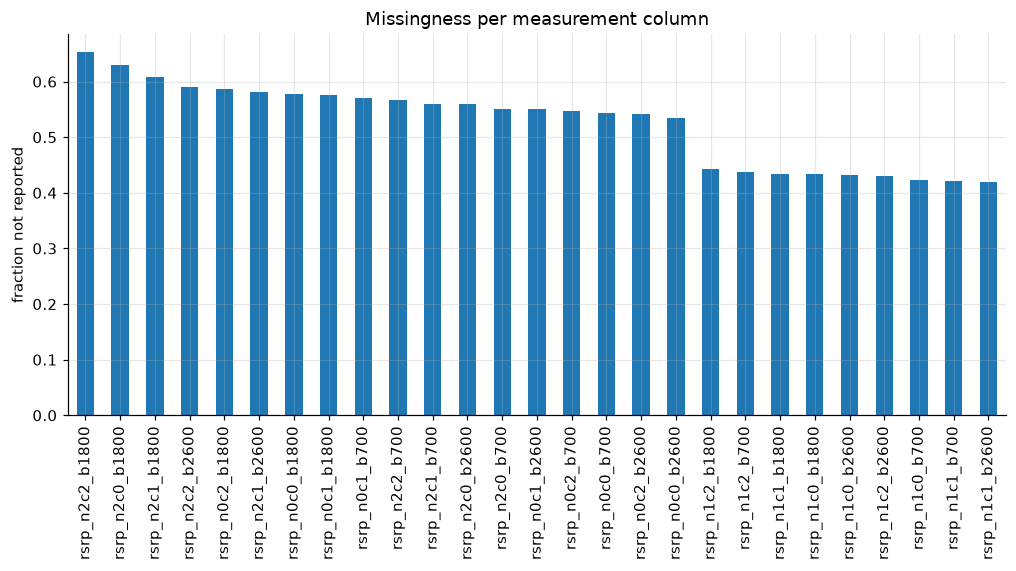

,missing_fraction
count,27.000000
mean,0.526194
std,0.073478
min,0.419428
25%,0.435936
50%,0.550597
75%,0.576685
max,0.652693


In [16]:
missing = mdt[measurement_columns].isna().mean().sort_values(ascending=False)

figure, axis = plt.subplots(figsize=(11.0, 4.5))
missing.plot.bar(ax=axis)
axis.set_ylabel("fraction not reported")
axis.set_title("Missingness per measurement column")
save_fig(figure, "missingness_per_column")
plt.show()

missing.describe().to_frame("missing_fraction")

ue_positions 10,066 rows, mdt 8,874 rows — 1,192 UEs (11.8%) heard nothing and were dropped


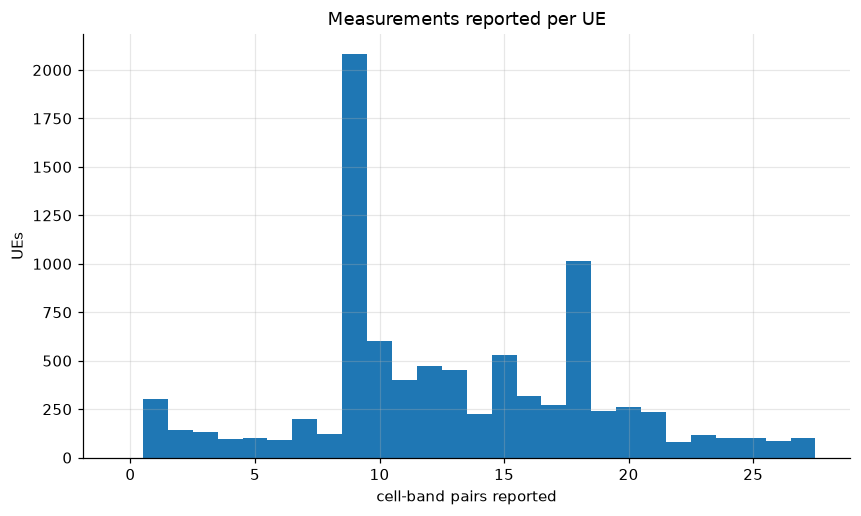

In [17]:
print(
    f"ue_positions {len(ue):,} rows, mdt {len(mdt):,} rows — "
    f"{len(ue) - len(mdt):,} UEs ({(len(ue) - len(mdt)) / len(ue):.1%}) heard nothing and were dropped"
)

reported = mdt[measurement_columns].notna()

figure, axis = plt.subplots()
axis.hist(reported.sum(axis=1), bins=np.arange(len(measurement_columns) + 2) - 0.5)
axis.set_xlabel("cell-band pairs reported")
axis.set_ylabel("UEs")
axis.set_title("Measurements reported per UE")
save_fig(figure, "measurements_reported_per_ue")
plt.show()

In [18]:
reports_per_ue = reported.sum(axis=1)
reports_table = reports_per_ue.describe().to_frame("cell-band pairs reported per UE")
save_table(reports_table.rename_axis("statistic").reset_index(), "reports_per_ue")
reports_table

,cell-band pairs reported per UE
count,8874.000000
mean,12.792765
std,5.745866
min,1.000000
25%,9.000000
50%,12.000000
75%,18.000000
max,27.000000


## 5. Univariate Distributions

Shape, scale, skew, and suspicious spikes. A spike at a round number, at zero, or
at a sensor's range limit is usually an encoded missing value in disguise.

In [19]:
ue.describe().T

,count,mean,std,min,25%,50%,75%,max
t_index,10066.0,336.194516,194.770911,0.000,169.00000,331.5000,506.00000,671.000
t_s,10066.0,302575.064574,175293.819995,0.000,152100.00000,298350.0000,455400.00000,603900.000
x,10066.0,57.005550,311.307925,-802.901,-170.43100,27.1900,309.32100,669.483
y,10066.0,-115.865726,291.099743,-688.391,-366.94675,-138.1565,150.15175,516.385
z,10066.0,1.500000,0.000000,1.500,1.50000,1.5000,1.50000,1.500
tile_col,10066.0,42.627459,15.560516,0.000,31.00000,41.0000,55.00000,73.000
tile_row,10066.0,28.135009,14.553133,0.000,16.00000,27.0000,41.00000,60.000
component,10066.0,1.268627,1.330361,-1.000,0.00000,1.0000,2.00000,3.000


In [20]:
mdt[position_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
t_index,8874.0,334.915258,195.412307,0.000,168.00000,330.0000,506.00000,671.000
t_s,8874.0,301423.732252,175871.076011,0.000,151200.00000,297000.0000,455400.00000,603900.000
x,8874.0,19.100555,270.200889,-802.901,-179.14625,4.6345,168.79625,669.483
y,8874.0,-152.775576,283.251315,-688.391,-380.87850,-241.2105,118.77200,515.963
z,8874.0,1.500000,0.000000,1.500,1.50000,1.5000,1.50000,1.500
tile_col,8874.0,40.732590,13.505059,0.000,31.00000,40.0000,48.00000,73.000
tile_row,8874.0,26.290174,14.160420,0.000,15.00000,22.0000,40.00000,60.000


In [21]:
pd.DataFrame(
    {
        "best_server_map": pd.Series(best_server.ravel()).describe(),
        "reported_mdt": pd.Series(mdt[measurement_columns].to_numpy().ravel()).describe(),
    }
)

,best_server_map,reported_mdt
count,9824.000000,113523.000000
mean,-88.358856,-98.276028
std,23.353411,28.387681
min,-186.637650,-220.671000
25%,-100.552414,-119.410500
50%,-84.771088,-97.474000
75%,-71.886963,-75.674000
max,-40.980370,-31.605000


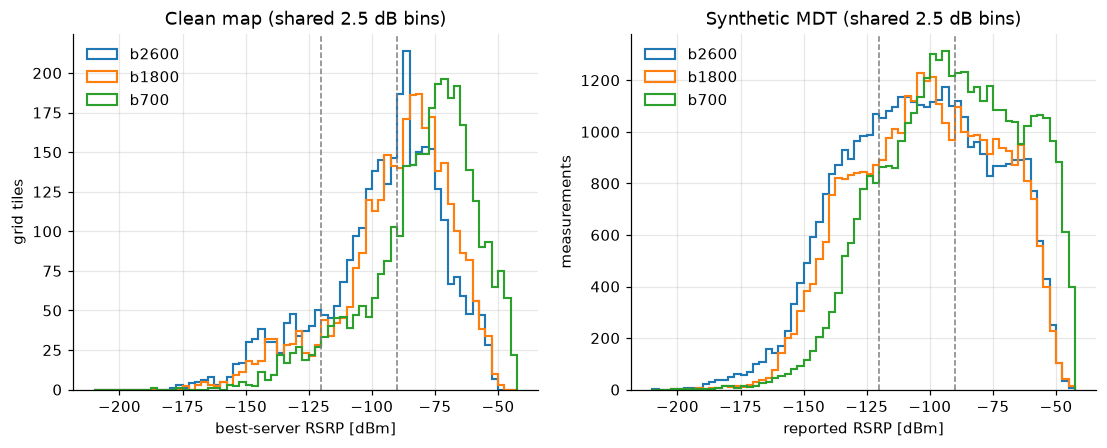

In [22]:
# One set of bin edges for every band, so bar heights compare across bands.
shared_edges = np.arange(-210.0, -40.0, 2.5)
hole_dbm = float(cfg.kpi.hole_dbm)
weak_dbm = float(cfg.kpi.weak_dbm)

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharex=True)
for index, band in enumerate(bands):
    layer = best_server[index]
    axes[0].hist(layer[np.isfinite(layer)], bins=shared_edges, histtype="step", lw=1.4, label=band)
    columns = [column for column in measurement_columns if column.endswith(f"_{band}")]
    observed = mdt[columns].to_numpy().ravel()
    axes[1].hist(
        observed[np.isfinite(observed)], bins=shared_edges, histtype="step", lw=1.4, label=band
    )
for axis in axes:
    for threshold in (hole_dbm, weak_dbm):
        axis.axvline(threshold, color="0.5", ls="--", lw=1)
    axis.legend()
axes[0].set(
    xlabel="best-server RSRP [dBm]", ylabel="grid tiles", title="Clean map (shared 2.5 dB bins)"
)
axes[1].set(
    xlabel="reported RSRP [dBm]", ylabel="measurements", title="Synthetic MDT (shared 2.5 dB bins)"
)
save_fig(figure, "rsrp_distributions_clean_vs_mdt")
plt.show()

In [23]:
rows = []
for index, band in enumerate(bands):
    layer = best_server[index][np.isfinite(best_server[index])]
    own_edges = np.histogram_bin_edges(layer, bins=60)
    rows.append(
        {
            "band": band,
            "tiles_reached": layer.size,
            "min_dbm": layer.min(),
            "median_dbm": np.median(layer),
            "max_dbm": layer.max(),
            "bin_width_with_own_60_bins_db": own_edges[1] - own_edges[0],
            "tiles_above_hole": int((layer > hole_dbm).sum()),
            "tiles_above_weak": int((layer > weak_dbm).sum()),
        }
    )
band_level = pd.DataFrame(rows)
save_table(band_level, "best_server_by_band")
band_level

,band,tiles_reached,min_dbm,median_dbm,max_dbm,bin_width_with_own_60_bins_db,tiles_above_hole,tiles_above_weak
0,b2600,3306,-177.975327,-90.641327,-50.332455,2.127380,2795,1615
1,b1800,3197,-173.768188,-86.202187,-49.113678,2.077576,2850,1828
2,b700,3321,-186.637650,-75.832436,-40.980370,2.427628,3119,2455


### Position Columns

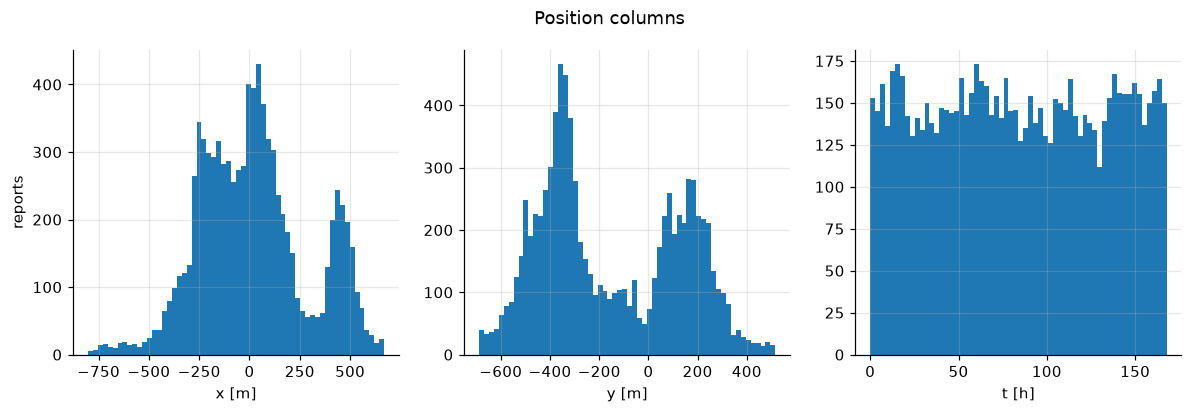

In [24]:
figure, axes = plt.subplots(1, 3, figsize=(13.0, 3.6))
for axis, column, scale, label in (
    (axes[0], "x", 1.0, "x [m]"),
    (axes[1], "y", 1.0, "y [m]"),
    (axes[2], "t_s", 3600.0, "t [h]"),
):
    axis.hist(mdt[column] / scale, bins=60)
    axis.set_xlabel(label)
axes[0].set_ylabel("reports")
figure.suptitle("Position columns")
save_fig(figure, "position_distributions")
plt.show()

### Reported RSRP per Cell-Band

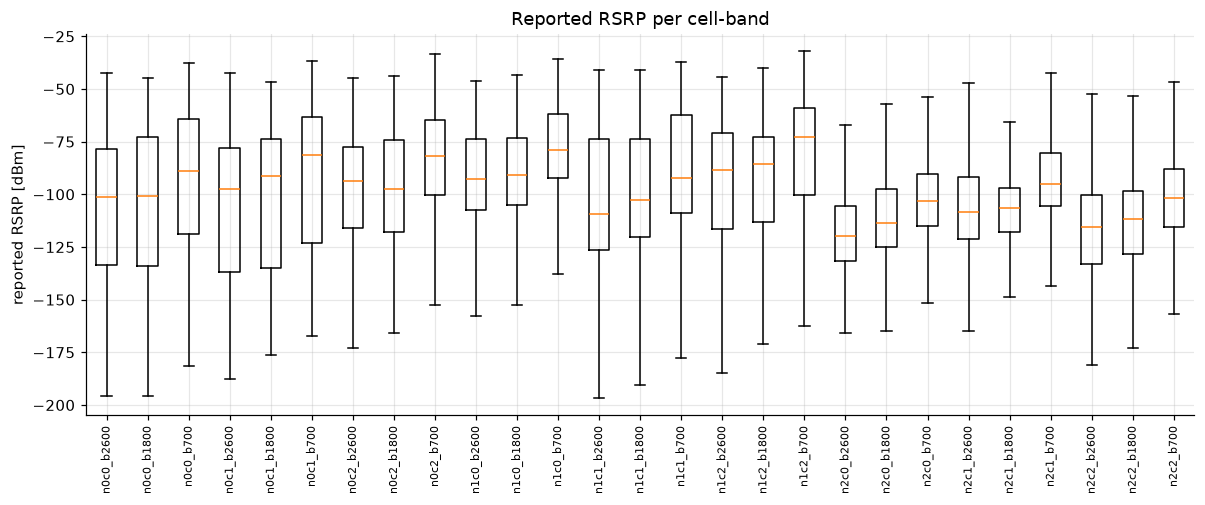

In [25]:
figure, axis = plt.subplots(figsize=(13.0, 4.5))
axis.boxplot([mdt[column].dropna().to_numpy() for column in measurement_columns], showfliers=False)
axis.set_xticks(
    range(1, len(measurement_columns) + 1),
    [column.removeprefix("rsrp_") for column in measurement_columns],
    rotation=90,
    fontsize=7,
)
axis.set_ylabel("reported RSRP [dBm]")
axis.set_title("Reported RSRP per cell-band")
save_fig(figure, "rsrp_per_cell_band")
plt.show()

### Per-Report Features

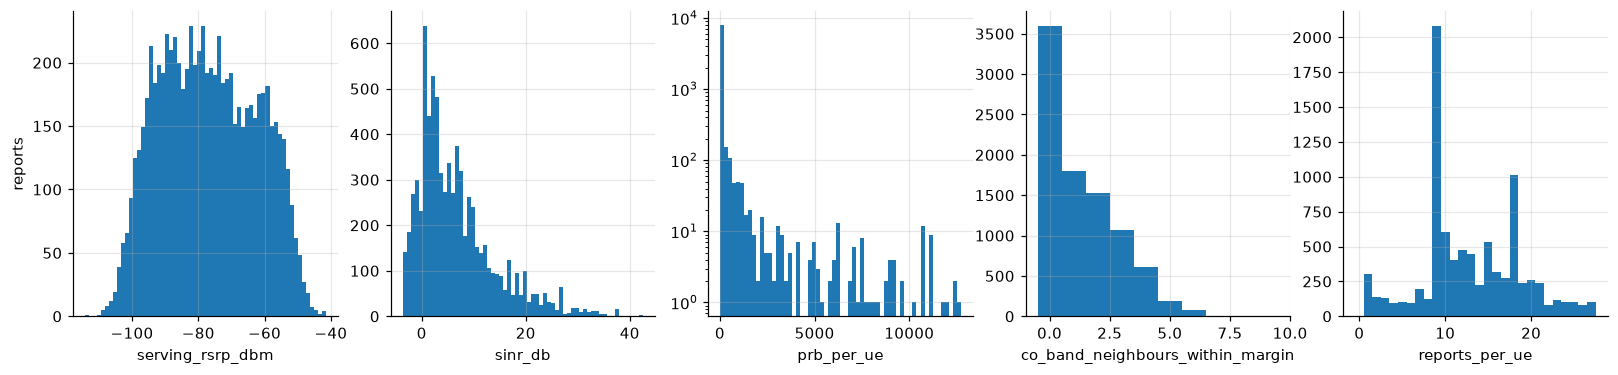

,count,mean,std,min,25%,50%,75%,max
serving_rsrp_dbm,7570.0,-76.939331,14.337958,-114.155000,-88.727000,-77.693000,-64.995250,-41.577000
sinr_db,7570.0,6.607839,7.481036,-3.676988,1.196363,4.760646,9.767180,42.565758
prb_per_ue,8517.0,212.606639,918.171704,7.857863,34.797034,65.996935,102.861708,12708.889777
co_band_neighbours_within_margin,8874.0,1.347983,1.463460,0.000000,0.000000,1.000000,2.000000,9.000000
reports_per_ue,8874.0,12.792765,5.745866,1.000000,9.000000,12.000000,18.000000,27.000000


In [26]:
# [report, tx, band]: mdt.py writes the measurement columns tx-major, band-minor.
per_layer = values.reshape(len(mdt), len(tx_names), len(bands))
filled = np.where(np.isfinite(per_layer), per_layer, -np.inf)
band_best = filled.max(axis=1)
margin_db = float(cfg.kpi.overlap_margin_db)
within_margin = np.isfinite(per_layer) & (per_layer >= band_best[:, None, :] - margin_db)
co_band_neighbours = np.clip(within_margin.sum(axis=1) - 1, 0, None).sum(axis=1)

ue_features = pd.DataFrame(
    {
        "serving_rsrp_dbm": serving_rsrp,
        "sinr_db": served["sinr_db"].to_numpy(),
        "prb_per_ue": served["prb_per_ue"].to_numpy(),
        "co_band_neighbours_within_margin": co_band_neighbours,
        "reports_per_ue": reports_per_ue.to_numpy(),
    }
)

figure, axes = plt.subplots(1, 5, figsize=(18.0, 3.6))
for axis, column in zip(axes, ue_features.columns):
    data = ue_features[column].replace([np.inf, -np.inf], np.nan).dropna()
    discrete = column in ("co_band_neighbours_within_margin", "reports_per_ue")
    bins = np.arange(data.max() + 2) - 0.5 if discrete else 60
    axis.hist(data, bins=bins, log=column == "prb_per_ue")
    axis.set_xlabel(column)
axes[0].set_ylabel("reports")
save_fig(figure, "per_ue_feature_distributions")
plt.show()

per_ue_summary = ue_features.replace([np.inf, -np.inf], np.nan).describe().T
save_table(per_ue_summary.rename_axis("feature").reset_index(), "per_ue_feature_summary")
per_ue_summary

In [27]:
serving_share = pd.DataFrame(
    {
        "reports": served["serving_band"].value_counts(),
        "share": served["serving_band"].value_counts(normalize=True),
    }
)
save_table(serving_share.rename_axis("serving_band").reset_index(), "serving_band_share")
serving_share

,reports,share
serving_band,,
b2600,6230,0.702051
blocked,1304,0.146946
b1800,1021,0.115055
b700,319,0.035948


## 6. Group Structure

**This section decides how the data is split.**

The intended split unit is the **scenario** — one drawn city plus the people in
it. A scenario is regenerated from its `scenario_id`, and train/validation/test
are meant to be split between whole scenarios so that no two rows sharing a city
straddle the boundary.

In [28]:
per_interval = ue.groupby("t_index").size()
per_tile = ue.groupby(["tile_row", "tile_col"]).size()

pd.DataFrame(
    {
        "value": {
            "scenarios on disk": 1,
            "scenario_id": manifest["scenario_id"],
            "intervals": int(ue["t_index"].nunique()),
            "rows per interval (mean)": round(per_interval.mean(), 1),
            "grid tiles occupied": int(per_tile.size),
            "grid tiles total": n_rows * n_cols,
            "rows per occupied tile (mean)": round(per_tile.mean(), 1),
            "rows per occupied tile (max)": int(per_tile.max()),
        }
    }
)

,value
scenarios on disk,1
scenario_id,scn_28d06a5bfb4c02e6
intervals,672
rows per interval (mean),15.0
grid tiles occupied,2333
grid tiles total,4514
rows per occupied tile (mean),4.3
rows per occupied tile (max),51


One scenario is on disk, so a between-scenario split is not yet possible — that
is a blocker for notebook 02, not a choice it can make.

Within the scenario, UEs are redrawn every interval and land repeatedly in the
same grid tiles, and every UE in a tile reads the *same* radio-map values. A
random row split would therefore put near-duplicate rows on both sides.

## 7. Relationships

What is worth modelling, and what is too predictive to be real. The MDT is
*derived* from the radio map, so predicting the map from the MDT is circular by
construction — the interesting question is how much the noise
destroys, which is what the residual below measures.

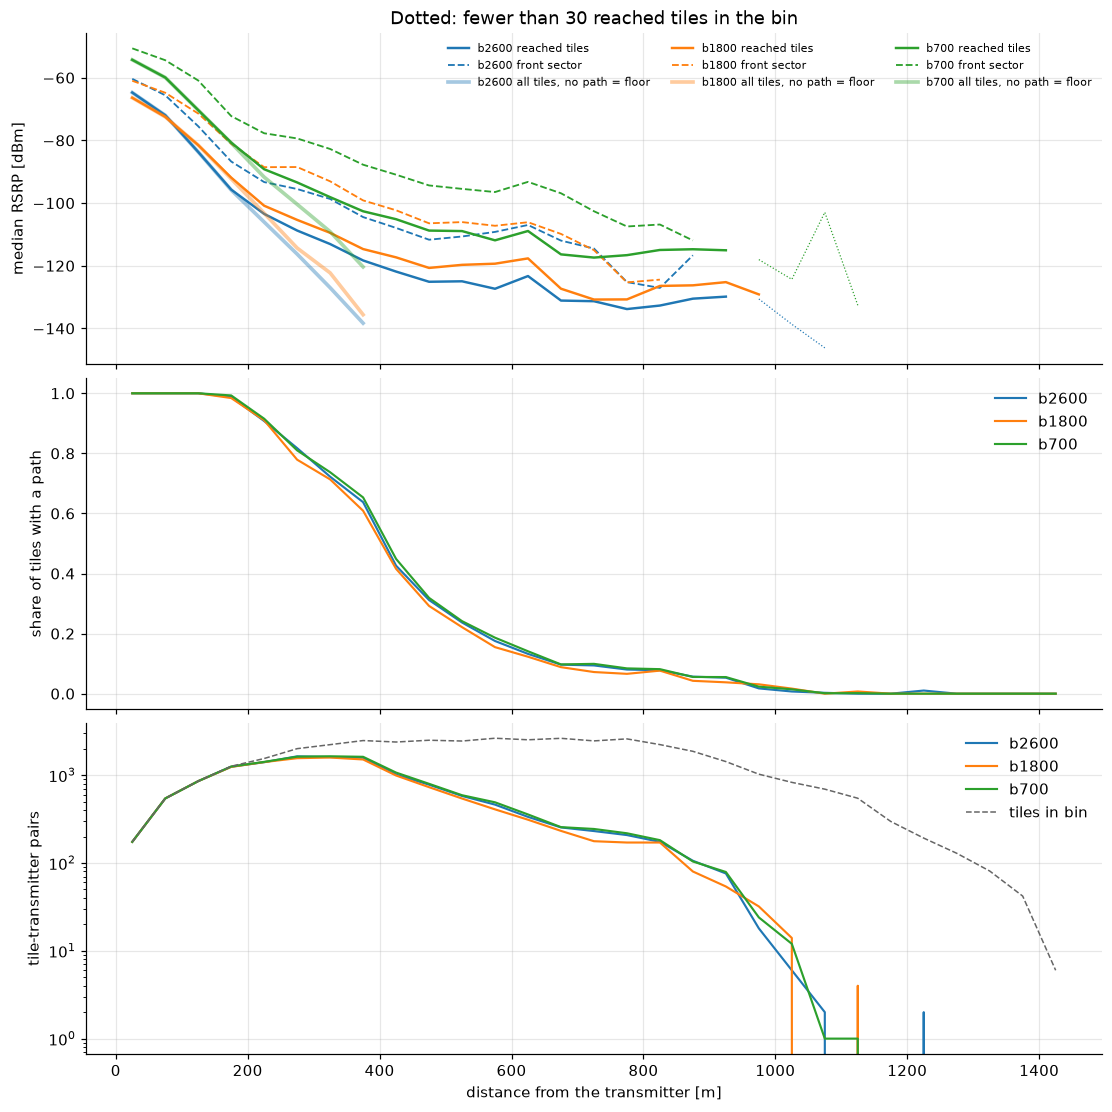

In [29]:
xs = origin_x + (np.arange(n_cols) + 0.5) * tile_size
ys = origin_y + (np.arange(n_rows) + 0.5) * tile_size
grid_x, grid_y = np.meshgrid(xs, ys)
distance = np.stack([np.hypot(grid_x - row.x, grid_y - row.y) for row in cells.itertuples()])
bearing = np.stack(
    [np.degrees(np.arctan2(grid_y - row.y, grid_x - row.x)) for row in cells.itertuples()]
)
off_boresight = (bearing - cells["azimuth_deg"].to_numpy()[:, None, None] + 180.0) % 360.0 - 180.0
front = np.abs(off_boresight) < 60.0

edges = np.arange(0.0, distance.max() + 50.0, 50.0)
midpoints = 0.5 * (edges[:-1] + edges[1:])
which_bin = np.digitize(distance, edges) - 1
MIN_TILES = 30

rows = []
for index, band in enumerate(bands):
    layer = rsrp[index]
    finite = np.isfinite(layer)
    floored = np.where(finite, layer, -np.inf)
    for bin_index, midpoint in enumerate(midpoints):
        in_bin = which_bin == bin_index
        reached = in_bin & finite
        reached_front = reached & front
        rows.append(
            {
                "band": band,
                "distance_m": midpoint,
                "tiles": int(in_bin.sum()),
                "reached": int(reached.sum()),
                "reached_front": int(reached_front.sum()),
                "reach_fraction": reached.sum() / in_bin.sum() if in_bin.any() else np.nan,
                "median_reached_dbm": np.median(layer[reached]) if reached.any() else np.nan,
                "median_reached_front_dbm": np.median(layer[reached_front])
                if reached_front.any()
                else np.nan,
                # No path counts as below every level, so this median leaves the
                # axis once fewer than half the bin's tiles are reached.
                "median_all_tiles_dbm": np.median(floored[in_bin]) if in_bin.any() else np.nan,
            }
        )
by_distance = pd.DataFrame(rows).replace(-np.inf, np.nan)
save_table(by_distance, "rsrp_by_distance")

figure, axes = plt.subplots(3, 1, figsize=(10.0, 10.0), sharex=True, constrained_layout=True)
for index, band in enumerate(bands):
    part = by_distance[by_distance["band"] == band]
    enough = part["reached"] >= MIN_TILES
    enough_front = part["reached_front"] >= MIN_TILES
    (line,) = axes[0].plot(
        part["distance_m"],
        part["median_reached_dbm"].where(enough),
        lw=1.6,
        label=f"{band} reached tiles",
    )
    axes[0].plot(
        part["distance_m"],
        part["median_reached_dbm"].where(~enough),
        lw=0.8,
        ls=":",
        color=line.get_color(),
    )
    axes[0].plot(
        part["distance_m"],
        part["median_reached_front_dbm"].where(enough_front),
        lw=1.2,
        ls="--",
        color=line.get_color(),
        label=f"{band} front sector",
    )
    axes[0].plot(
        part["distance_m"],
        part["median_all_tiles_dbm"],
        lw=2.4,
        alpha=0.4,
        color=line.get_color(),
        label=f"{band} all tiles, no path = floor",
    )
    axes[1].plot(
        part["distance_m"], part["reach_fraction"], lw=1.4, color=line.get_color(), label=band
    )
    axes[2].plot(part["distance_m"], part["reached"], lw=1.4, color=line.get_color(), label=band)
axes[2].plot(
    midpoints,
    by_distance[by_distance["band"] == bands[0]]["tiles"],
    color="0.4",
    lw=1.0,
    ls="--",
    label="tiles in bin",
)
axes[0].set_ylabel("median RSRP [dBm]")
axes[0].set_title(f"Dotted: fewer than {MIN_TILES} reached tiles in the bin")
axes[1].set_ylabel("share of tiles with a path")
axes[2].set_ylabel("tile-transmitter pairs")
axes[2].set_yscale("log")
axes[2].set_xlabel("distance from the transmitter [m]")
axes[0].legend(fontsize=7, ncol=3)
axes[1].legend()
axes[2].legend()
save_fig(figure, "path_loss_by_band")
plt.show()

reported minus clean: mean -0.003 dB, sd 3.994 dB (configured rsrp_noise_sigma_db = 4.0)


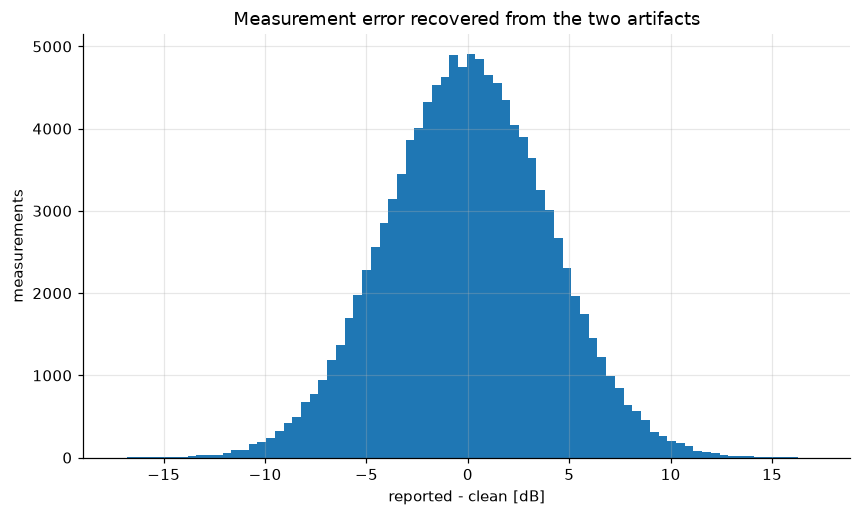

In [30]:
row = mdt["tile_row"].to_numpy()
col = mdt["tile_col"].to_numpy()
# [band, tx, ue] -> [ue, tx, band] -> flattened tx-major, band-minor, matching mdt.
clean = rsrp[:, :, row, col].transpose(2, 1, 0).reshape(len(mdt), -1).astype(np.float64)
observed = mdt[measurement_columns].to_numpy()
both = np.isfinite(clean) & np.isfinite(observed)
residual = observed[both] - clean[both]

print(
    f"reported minus clean: mean {residual.mean():+.3f} dB, sd {residual.std():.3f} dB "
    f"(configured rsrp_noise_sigma_db = {cfg.simulation.mdt.rsrp_noise_sigma_db})"
)

figure, axis = plt.subplots()
axis.hist(residual, bins=80)
axis.set_xlabel("reported - clean [dB]")
axis.set_ylabel("measurements")
axis.set_title("Measurement error recovered from the two artifacts")
save_fig(figure, "measurement_error_residual")
plt.show()

In [31]:
pd.DataFrame(
    {
        band: pd.Series(
            np.where(np.isfinite(best_server[index]), best_server[index], np.nan).ravel()
        )
        for index, band in enumerate(bands)
    }
).corr()

,b2600,b1800,b700
b2600,1.000000,0.782439,0.891308
b1800,0.782439,1.000000,0.851296
b700,0.891308,0.851296,1.000000


In [32]:
first_band = [column for column in measurement_columns if column.endswith(f"_{bands[0]}")]
mdt[first_band].corr().round(2)

,rsrp_n0c0_b2600,rsrp_n0c1_b2600,rsrp_n0c2_b2600,rsrp_n1c0_b2600,rsrp_n1c1_b2600,rsrp_n1c2_b2600,rsrp_n2c0_b2600,rsrp_n2c1_b2600,rsrp_n2c2_b2600
rsrp_n0c0_b2600,1.00,0.81,0.67,-0.32,-0.47,-0.40,-0.37,-0.40,-0.41
rsrp_n0c1_b2600,0.81,1.00,0.54,-0.62,-0.69,-0.66,-0.35,-0.44,-0.47
rsrp_n0c2_b2600,0.67,0.54,1.00,-0.06,-0.20,-0.17,-0.29,-0.32,-0.33
rsrp_n1c0_b2600,-0.32,-0.62,-0.06,1.00,0.77,0.75,-0.31,-0.02,-0.19
rsrp_n1c1_b2600,-0.47,-0.69,-0.20,0.77,1.00,0.78,-0.35,-0.17,-0.21
rsrp_n1c2_b2600,-0.40,-0.66,-0.17,0.75,0.78,1.00,-0.22,-0.11,-0.05
rsrp_n2c0_b2600,-0.37,-0.35,-0.29,-0.31,-0.35,-0.22,1.00,0.07,0.48
rsrp_n2c1_b2600,-0.40,-0.44,-0.32,-0.02,-0.17,-0.11,0.07,1.00,0.43
rsrp_n2c2_b2600,-0.41,-0.47,-0.33,-0.19,-0.21,-0.05,0.48,0.43,1.00


### Correlation of Every Cell-Band Pair

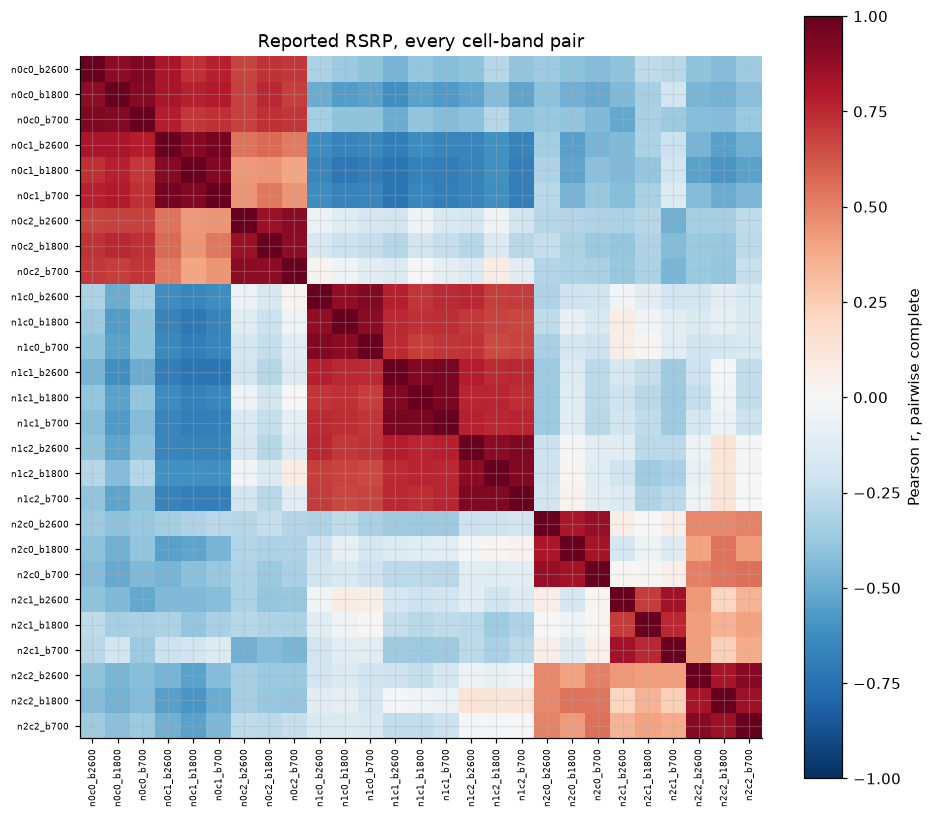

In [33]:
labels = [column.removeprefix("rsrp_") for column in measurement_columns]
rsrp_corr = mdt[measurement_columns].corr()
save_table(rsrp_corr.rename_axis("column").reset_index(), "rsrp_correlation")

figure, axis = plt.subplots(figsize=(10.0, 9.0))
image = axis.imshow(rsrp_corr.to_numpy(), vmin=-1.0, vmax=1.0, cmap="RdBu_r")
axis.set_xticks(range(len(labels)), labels, rotation=90, fontsize=6)
axis.set_yticks(range(len(labels)), labels, fontsize=6)
figure.colorbar(image, ax=axis, label="Pearson r, pairwise complete")
axis.set_title("Reported RSRP, every cell-band pair")
save_fig(figure, "rsrp_correlation_heatmap")
plt.show()

### Same Cell, Low Band Against High Band

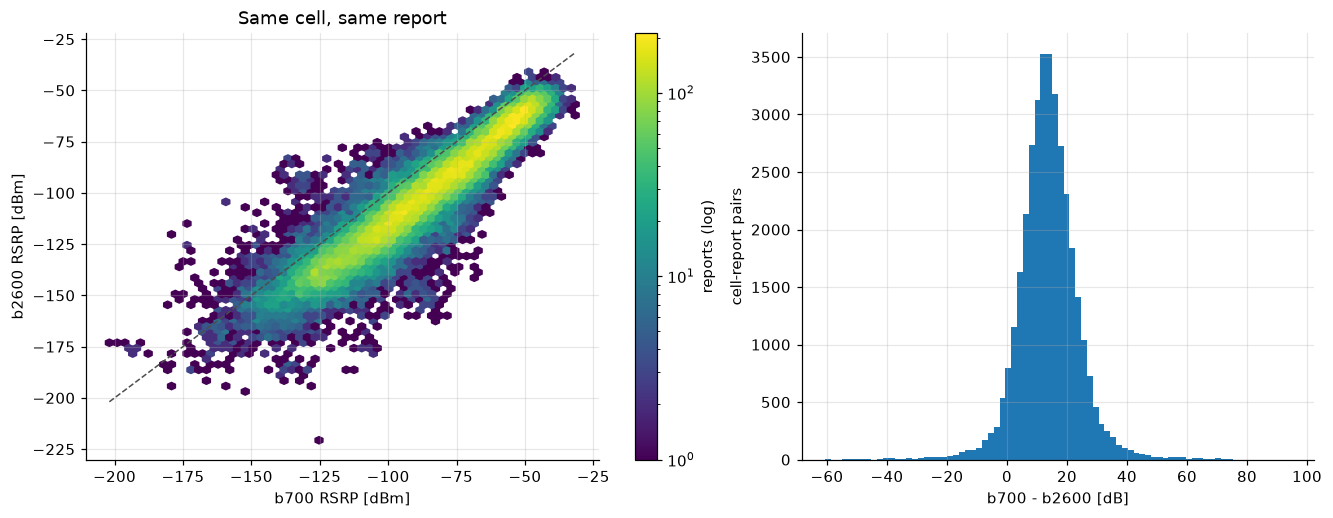

,b700 - b2600 [dB]
count,35556.000000
mean,13.772311
std,10.032394
min,-60.680000
25%,8.271000
50%,13.534500
75%,19.150000
max,94.581000


In [34]:
low_band = bands[int(np.argmin(radio["band_hz"]))]
high_band = bands[int(np.argmax(radio["band_hz"]))]
low_values = np.concatenate([mdt[f"rsrp_{tx}_{low_band}"].to_numpy() for tx in tx_names])
high_values = np.concatenate([mdt[f"rsrp_{tx}_{high_band}"].to_numpy() for tx in tx_names])
both_heard = np.isfinite(low_values) & np.isfinite(high_values)
band_gap = low_values[both_heard] - high_values[both_heard]

figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), constrained_layout=True)
image = axes[0].hexbin(low_values[both_heard], high_values[both_heard], gridsize=60, bins="log")
limits = [np.nanmin(low_values), np.nanmax(low_values)]
axes[0].plot(limits, limits, color="0.3", lw=1.0, ls="--")
axes[0].set(
    xlabel=f"{low_band} RSRP [dBm]",
    ylabel=f"{high_band} RSRP [dBm]",
    title="Same cell, same report",
)
figure.colorbar(image, ax=axes[0], label="reports (log)")
axes[1].hist(band_gap, bins=80)
axes[1].set(xlabel=f"{low_band} - {high_band} [dB]", ylabel="cell-report pairs")
save_fig(figure, "same_cell_band_gap")
plt.show()

band_gap_table = pd.Series(band_gap).describe().to_frame(f"{low_band} - {high_band} [dB]")
save_table(band_gap_table.rename_axis("statistic").reset_index(), "same_cell_band_gap")
band_gap_table

## 8. Temporal and Spatial Structure

Every interval draws a fresh crowd from the same hotspots with time-varying
mixture mass, so the UE distribution moves while the city and the radio map stay
put. The panels below are consecutive intervals over a short window; crosses mark
the hotspot centres and triangles the cells.

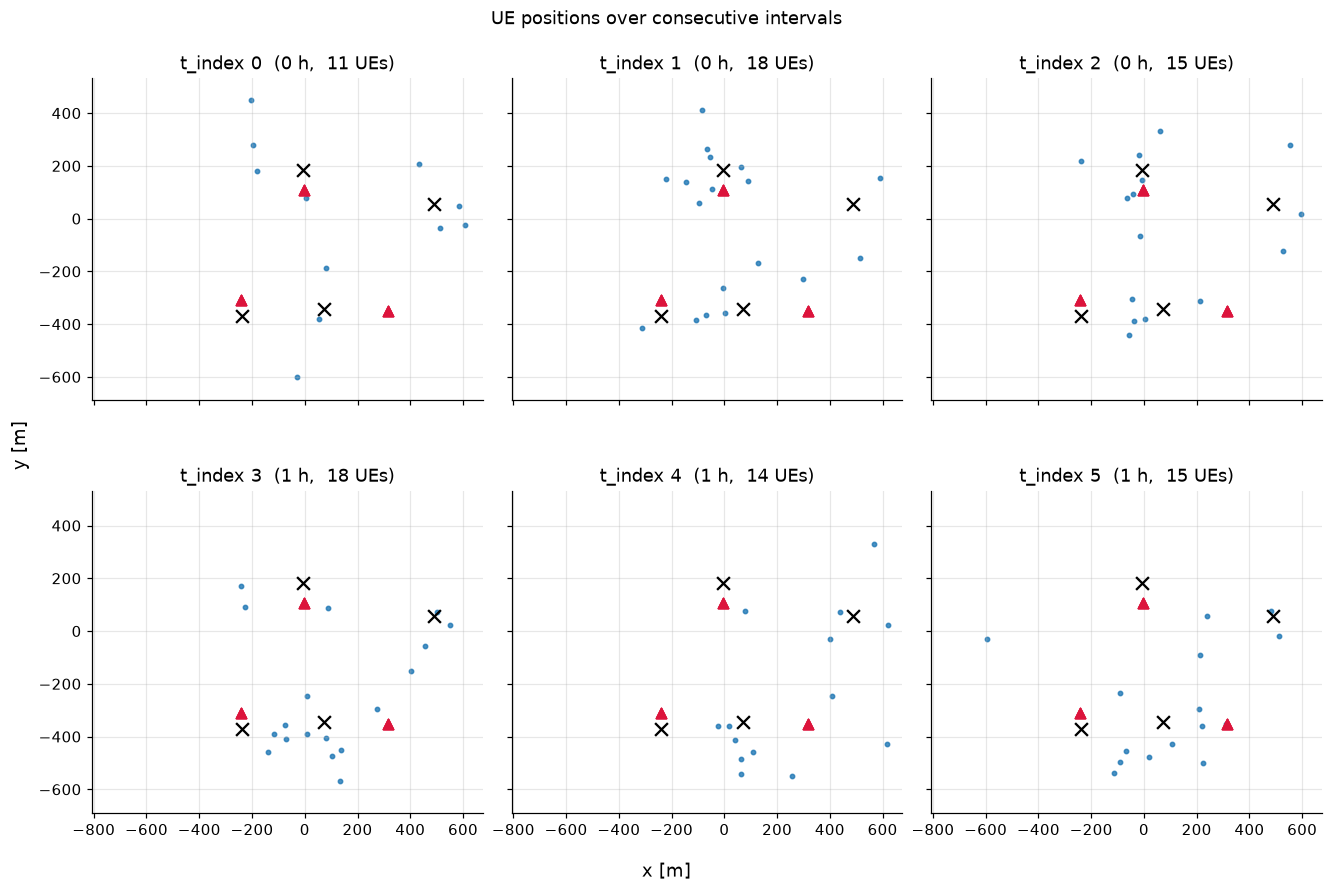

In [35]:
T_WINDOW = list(range(6))
PANEL_COLUMNS = 3

panel_rows = int(np.ceil(len(T_WINDOW) / PANEL_COLUMNS))
figure, axes = plt.subplots(
    panel_rows,
    PANEL_COLUMNS,
    figsize=(4.0 * PANEL_COLUMNS, 4.0 * panel_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for axis, t_index in zip(np.ravel(axes), T_WINDOW):
    part = ue[ue["t_index"] == t_index]
    axis.scatter(part["x"], part["y"], s=8, alpha=0.8)
    axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=70, color="black", zorder=4)
    axis.scatter(cells["x"], cells["y"], marker="^", s=45, color="crimson", zorder=3)
    axis.set_xlim(extent[0], extent[1])
    axis.set_ylim(extent[2], extent[3])
    axis.set_aspect("equal")
    hours_in = part["t_s"].iloc[0] / 3600.0 if len(part) else float("nan")
    axis.set_title(f"t_index {t_index}  ({hours_in:.0f} h,  {len(part)} UEs)")
for axis in np.ravel(axes)[len(T_WINDOW) :]:
    axis.set_visible(False)
figure.supxlabel("x [m]")
figure.supylabel("y [m]")
figure.suptitle("UE positions over consecutive intervals")
save_fig(figure, "ue_positions_time_window")
plt.show()

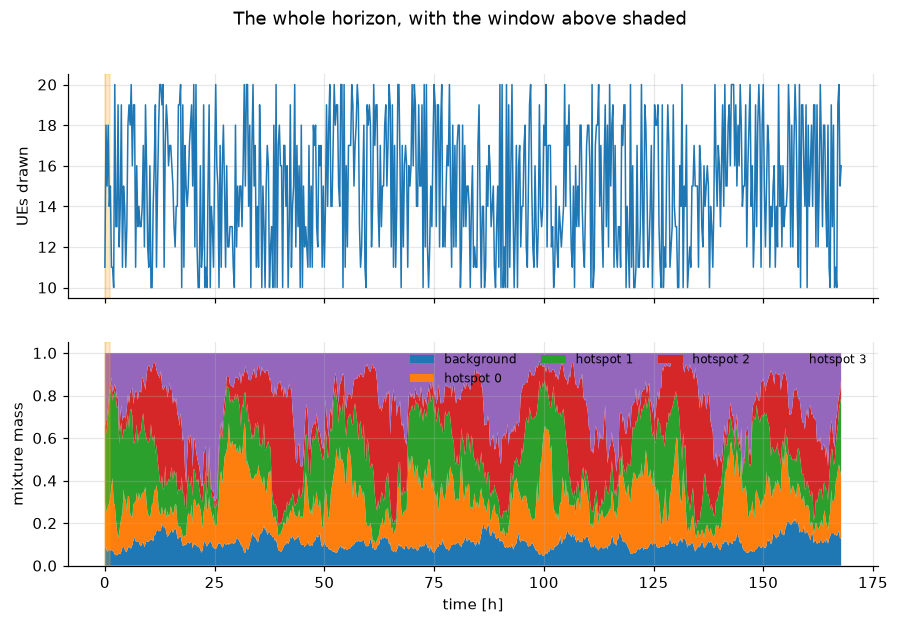

In [36]:
per_time = ue.groupby("t_s").size()
mass = np.asarray(manifest["time"]["component_mass"])
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0

figure, axes = plt.subplots(2, 1, figsize=(9.5, 5.8), sharex=True)
axes[0].plot(per_time.index / 3600.0, per_time.to_numpy(), lw=1.0)
axes[0].set_ylabel("UEs drawn")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["background"] + [f"hotspot {index}" for index in range(mass.shape[1] - 1)],
)
axes[1].set_ylabel("mixture mass")
axes[1].set_xlabel("time [h]")
axes[1].legend(loc="upper right", ncol=4, fontsize=8)
for axis in axes:
    axis.axvspan(hours[T_WINDOW[0]], hours[T_WINDOW[-1]], color="orange", alpha=0.25)
figure.suptitle("The whole horizon, with the window above shaded")
save_fig(figure, "time_schedule_full_horizon")
plt.show()

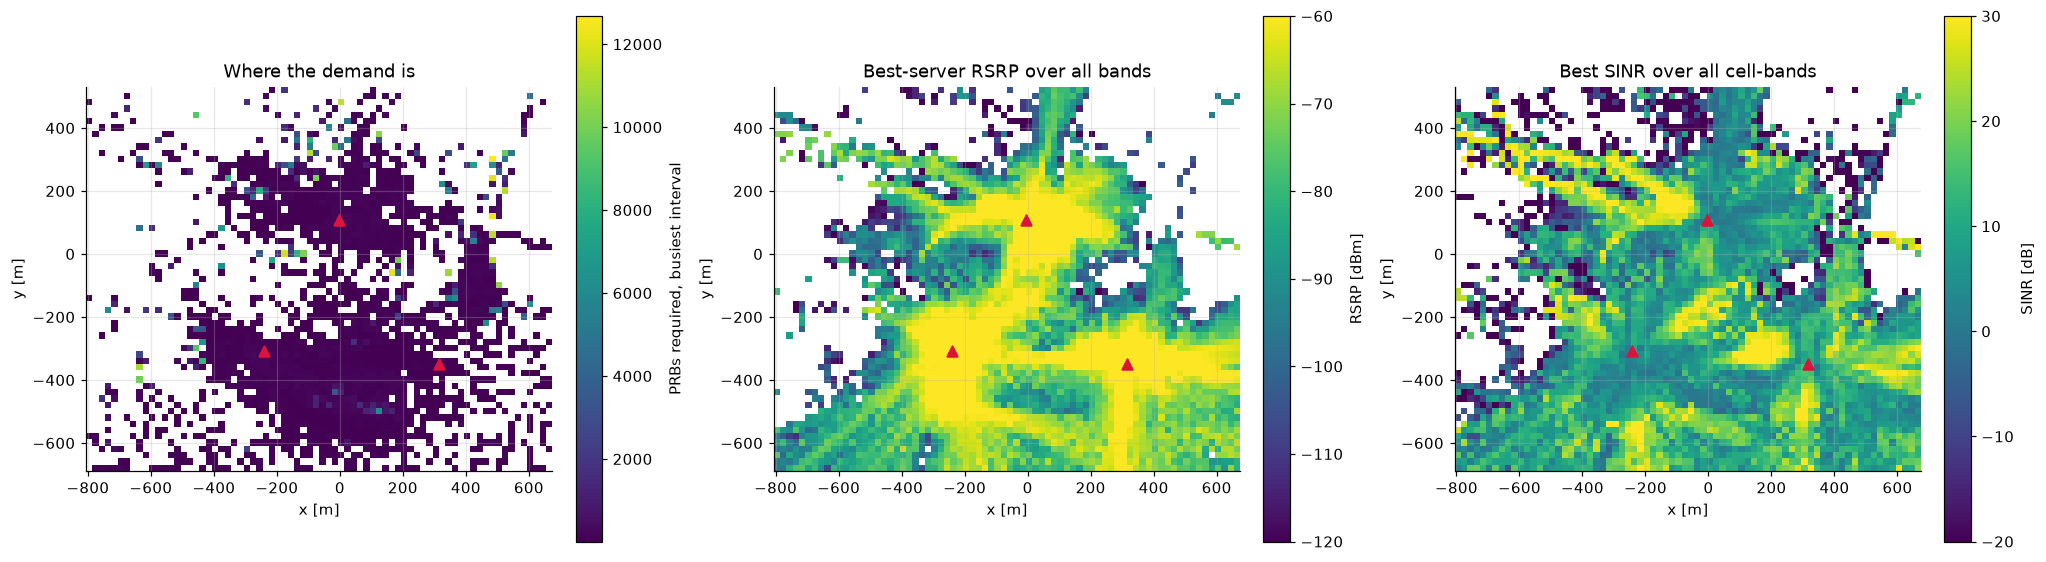

In [37]:
# The demand map the MDT stage wrote (PRBs per tile per interval, served from the
# reports), beside the signal map: best-server RSRP and best SINR over all bands.
from src.evaluation import maps

with np.load(out.demand_map_file, allow_pickle=False) as archive:
    prb_required = archive["prb_required"]
overall = np.where(np.isfinite(best_server), best_server, np.nan).max(axis=0)
# The solver's SINR, best over every cell-band. -inf where no ray reached,
# which NaN leaves blank.
overall_sinr = maps.best_sinr(sinr)
overall_sinr = np.where(np.isfinite(overall_sinr), overall_sinr, np.nan)
peak_demand = prb_required.max(axis=0)

figure, axes = plt.subplots(1, 3, figsize=(18.5, 5.0), constrained_layout=True)
for axis, values, label, title, limits in (
    (
        axes[0],
        np.where(peak_demand > 0, peak_demand, np.nan),
        "PRBs required, busiest interval",
        "Where the demand is",
        {},
    ),
    (
        axes[1],
        overall,
        "RSRP [dBm]",
        "Best-server RSRP over all bands",
        {"vmin": -120.0, "vmax": -60.0},
    ),
    (
        axes[2],
        overall_sinr,
        "SINR [dB]",
        "Best SINR over all cell-bands",
        {"vmin": -20.0, "vmax": 30.0},
    ),
):
    image = axis.imshow(values, origin="lower", extent=extent, aspect="equal", **limits)
    figure.colorbar(image, ax=axis, label=label)
    axis.scatter(cells["x"], cells["y"], marker="^", s=45, color="crimson", zorder=3)
    axis.set_xlabel("x [m]")
    axis.set_ylabel("y [m]")
    axis.set_title(title)
save_fig(figure, "demand_vs_coverage")
plt.show()

Demand is drawn towards densely built ground, which is also where propagation is
worst. That tension between the demand and the signal panels is the problem the project is about.

### Per-Interval Series

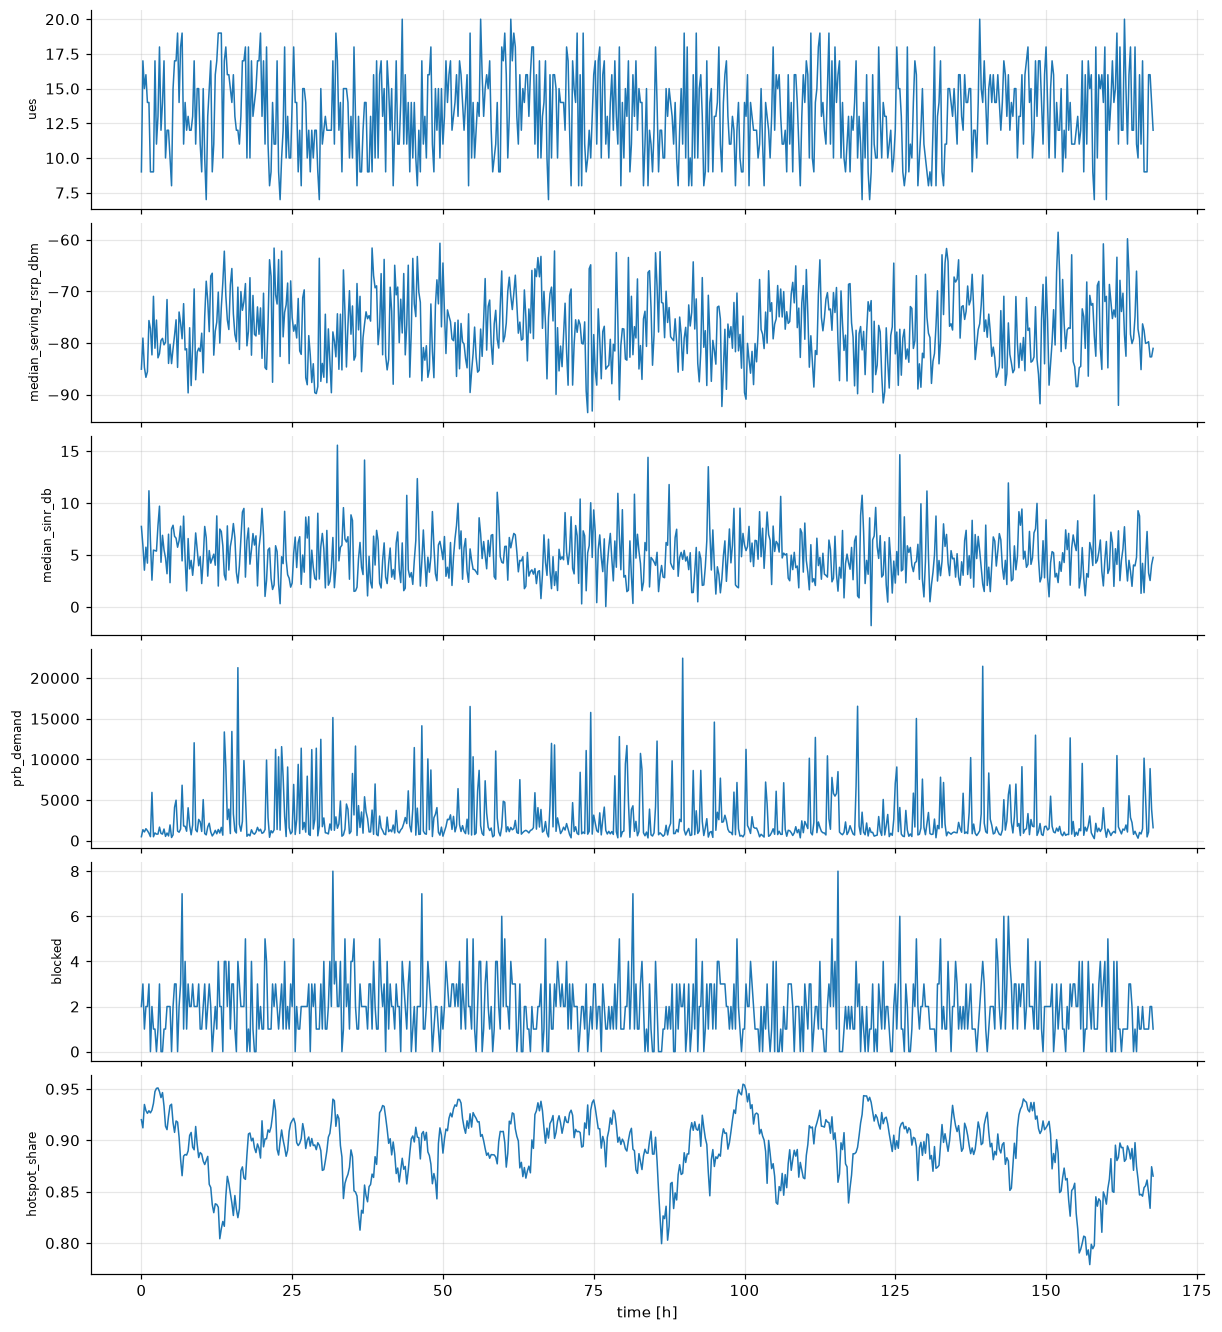

In [38]:
mass = np.asarray(manifest["time"]["component_mass"])
interval_stats = (
    served.assign(
        t_s=mdt["t_s"].to_numpy(),
        serving_rsrp_dbm=serving_rsrp,
        blocked=served["band"].to_numpy() < 0,
    )
    .groupby("t_index")
    .agg(
        t_s=("t_s", "first"),
        ues=("band", "size"),
        median_serving_rsrp_dbm=("serving_rsrp_dbm", "median"),
        median_sinr_db=("sinr_db", "median"),
        prb_demand=("prb_per_ue", "sum"),
        blocked=("blocked", "sum"),
    )
)
interval_stats["hotspot_share"] = mass[interval_stats.index, 1:].sum(axis=1)
interval_stats["hour_of_day"] = (interval_stats["t_s"] // 3600).astype(int) % 24
interval_stats["day"] = (interval_stats["t_s"] // 86400).astype(int)
save_table(interval_stats.reset_index(), "per_interval_stats")

series = [
    "ues",
    "median_serving_rsrp_dbm",
    "median_sinr_db",
    "prb_demand",
    "blocked",
    "hotspot_share",
]
figure, axes = plt.subplots(
    len(series), 1, figsize=(11.0, 12.0), sharex=True, constrained_layout=True
)
for axis, column in zip(axes, series):
    axis.plot(interval_stats["t_s"] / 3600.0, interval_stats[column], lw=1.0)
    axis.set_ylabel(column, fontsize=8)
axes[-1].set_xlabel("time [h]")
save_fig(figure, "per_interval_series")
plt.show()

### Hour of Day and Day

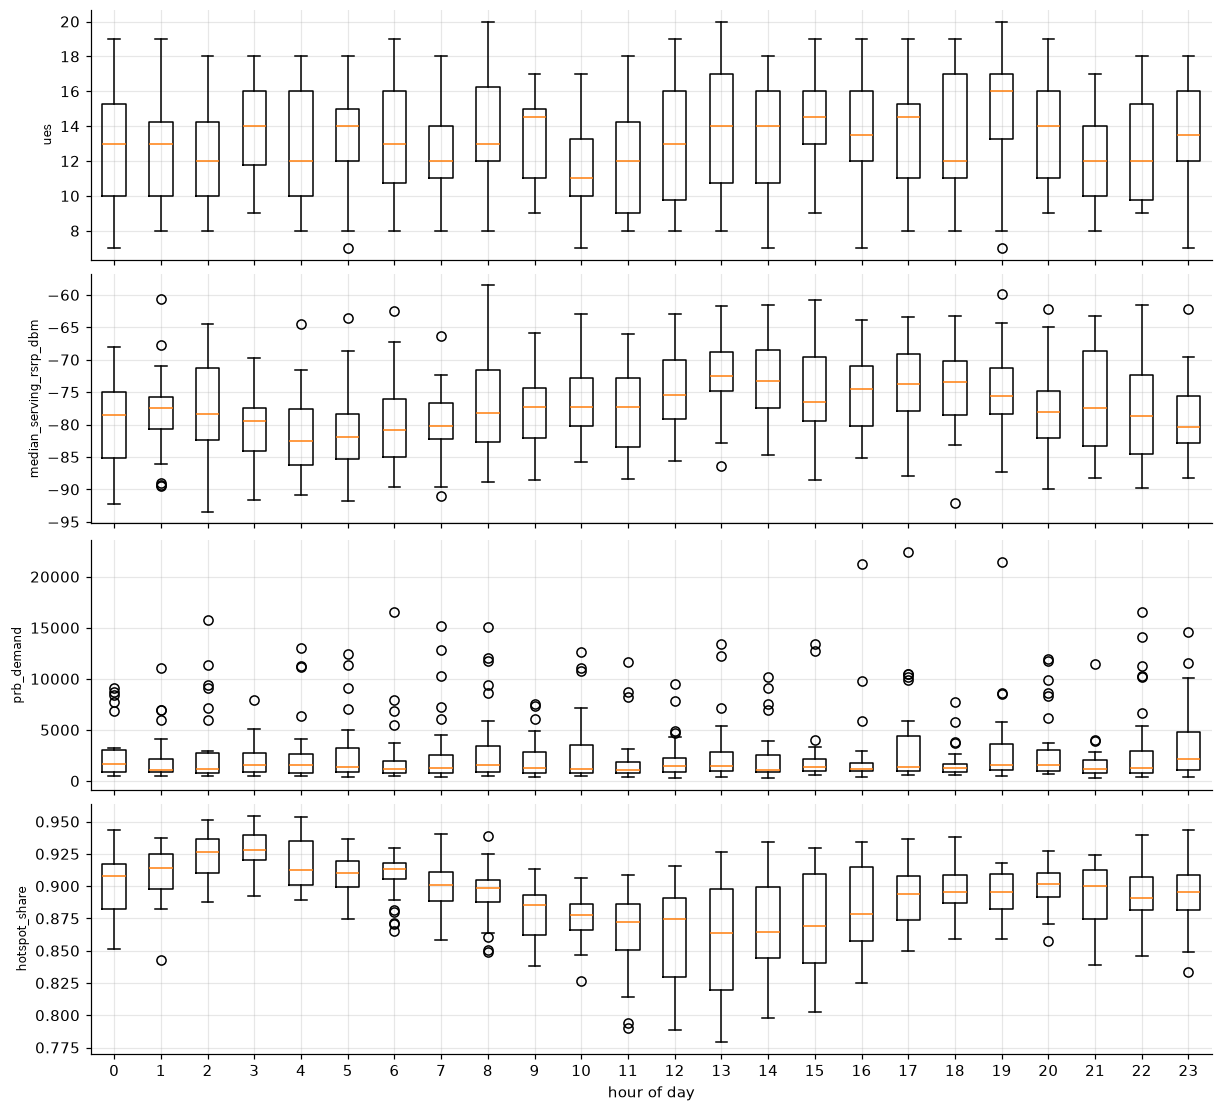

,ues,prb_demand,blocked,median_serving_rsrp_dbm
day,,,,
0,13.729167,2775.120977,1.958333,-76.641297
1,12.552083,3164.885554,2.250000,-77.285990
2,14.010417,2638.223837,2.062500,-76.321406
3,12.885417,3034.780305,1.791667,-77.943667
4,12.833333,2558.743501,1.760417,-77.231859
5,12.791667,2417.381097,1.885417,-77.759563
6,13.635417,2273.060023,1.875000,-77.365318


In [39]:
columns = ["ues", "median_serving_rsrp_dbm", "prb_demand", "hotspot_share"]
figure, axes = plt.subplots(
    len(columns), 1, figsize=(11.0, 10.0), sharex=True, constrained_layout=True
)
hours = sorted(interval_stats["hour_of_day"].unique())
for axis, column in zip(axes, columns):
    axis.boxplot(
        [interval_stats.loc[interval_stats["hour_of_day"] == hour, column] for hour in hours]
    )
    axis.set_ylabel(column, fontsize=8)
axes[-1].set_xticks(range(1, len(hours) + 1), hours)
axes[-1].set_xlabel("hour of day")
save_fig(figure, "hour_of_day_boxplots")
plt.show()

by_day = interval_stats.groupby("day")[
    ["ues", "prb_demand", "blocked", "median_serving_rsrp_dbm"]
].mean()
save_table(by_day.reset_index(), "per_day_means")
by_day

### Autocorrelation

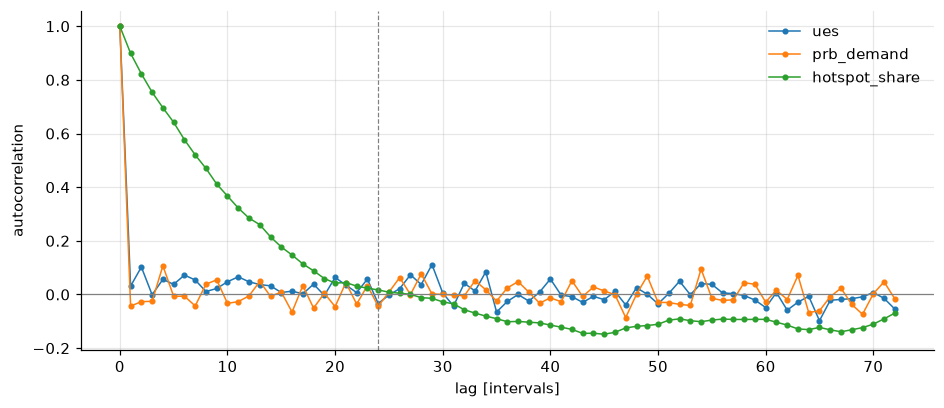

In [40]:
def autocorrelation(series, max_lag):
    """Sample autocorrelation at lags 0..max_lag."""
    centred = np.asarray(series, dtype=float) - np.mean(series)
    denominator = np.sum(centred * centred)
    return np.array(
        [
            np.sum(centred[: len(centred) - lag] * centred[lag:]) / denominator
            for lag in range(max_lag + 1)
        ]
    )


MAX_LAG = 72
lags = np.arange(MAX_LAG + 1)
figure, axis = plt.subplots(figsize=(10.0, 4.0))
for column in ("ues", "prb_demand", "hotspot_share"):
    axis.plot(
        lags, autocorrelation(interval_stats[column], MAX_LAG), marker=".", lw=1.0, label=column
    )
axis.axhline(0.0, color="0.5", lw=0.8)
axis.axvline(24, color="0.5", lw=0.8, ls="--")
axis.set(xlabel="lag [intervals]", ylabel="autocorrelation")
axis.legend()
save_fig(figure, "per_interval_autocorrelation")
plt.show()

### PRB Load per Cell-Band

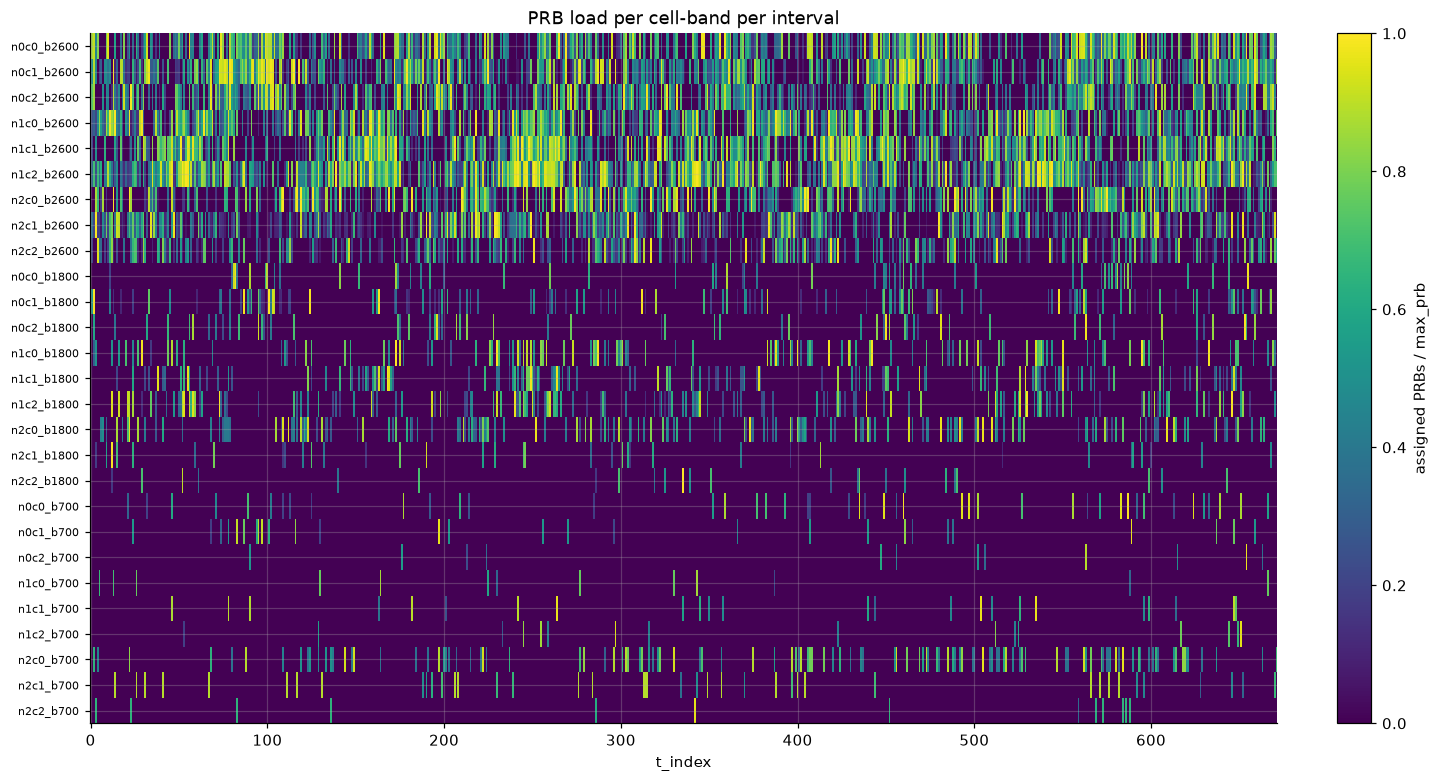

,mean_utilisation,peak_utilisation,intervals_at_limit
n0c0_b2600,0.352572,0.994652,0
n0c1_b2600,0.380096,0.999132,2
n0c2_b2600,0.324665,0.987975,0
n1c0_b2600,0.383420,0.994141,0
n1c1_b2600,0.396552,0.989706,0
n1c2_b2600,0.481218,0.997394,0
n2c0_b2600,0.309045,0.998966,0
n2c1_b2600,0.255929,0.997213,0
n2c2_b2600,0.187072,0.979394,0
n0c0_b1800,0.048259,0.977437,0


In [41]:
has_cell = served["band"] >= 0
cell_load = (
    served[has_cell]
    .groupby(["band", "tx", "t_index"])["prb_per_ue"]
    .sum()
    .unstack("t_index", fill_value=0.0)
    .reindex(columns=interval_stats.index, fill_value=0.0)
)
utilisation = cell_load.div(
    capacity_spec.max_prb[
        cell_load.index.get_level_values("band"), cell_load.index.get_level_values("tx")
    ],
    axis=0,
)
layer_labels = [f"{tx_names[tx]}_{bands[band]}" for band, tx in cell_load.index]

figure, axis = plt.subplots(figsize=(13.0, 7.0), constrained_layout=True)
image = axis.imshow(
    utilisation.to_numpy(), aspect="auto", vmin=0.0, vmax=1.0, interpolation="nearest"
)
axis.set_yticks(range(len(layer_labels)), layer_labels, fontsize=7)
axis.set_xlabel("t_index")
figure.colorbar(image, ax=axis, label="assigned PRBs / max_prb")
axis.set_title("PRB load per cell-band per interval")
save_fig(figure, "cell_band_prb_load")
plt.show()

load_summary = pd.DataFrame(
    {
        "mean_utilisation": utilisation.mean(axis=1).to_numpy(),
        "peak_utilisation": utilisation.max(axis=1).to_numpy(),
        "intervals_at_limit": (utilisation >= 0.999).sum(axis=1).to_numpy(),
    },
    index=layer_labels,
)
save_table(load_summary.rename_axis("cell_band").reset_index(), "cell_band_load_summary")
load_summary

### Serving and Demand by Tile

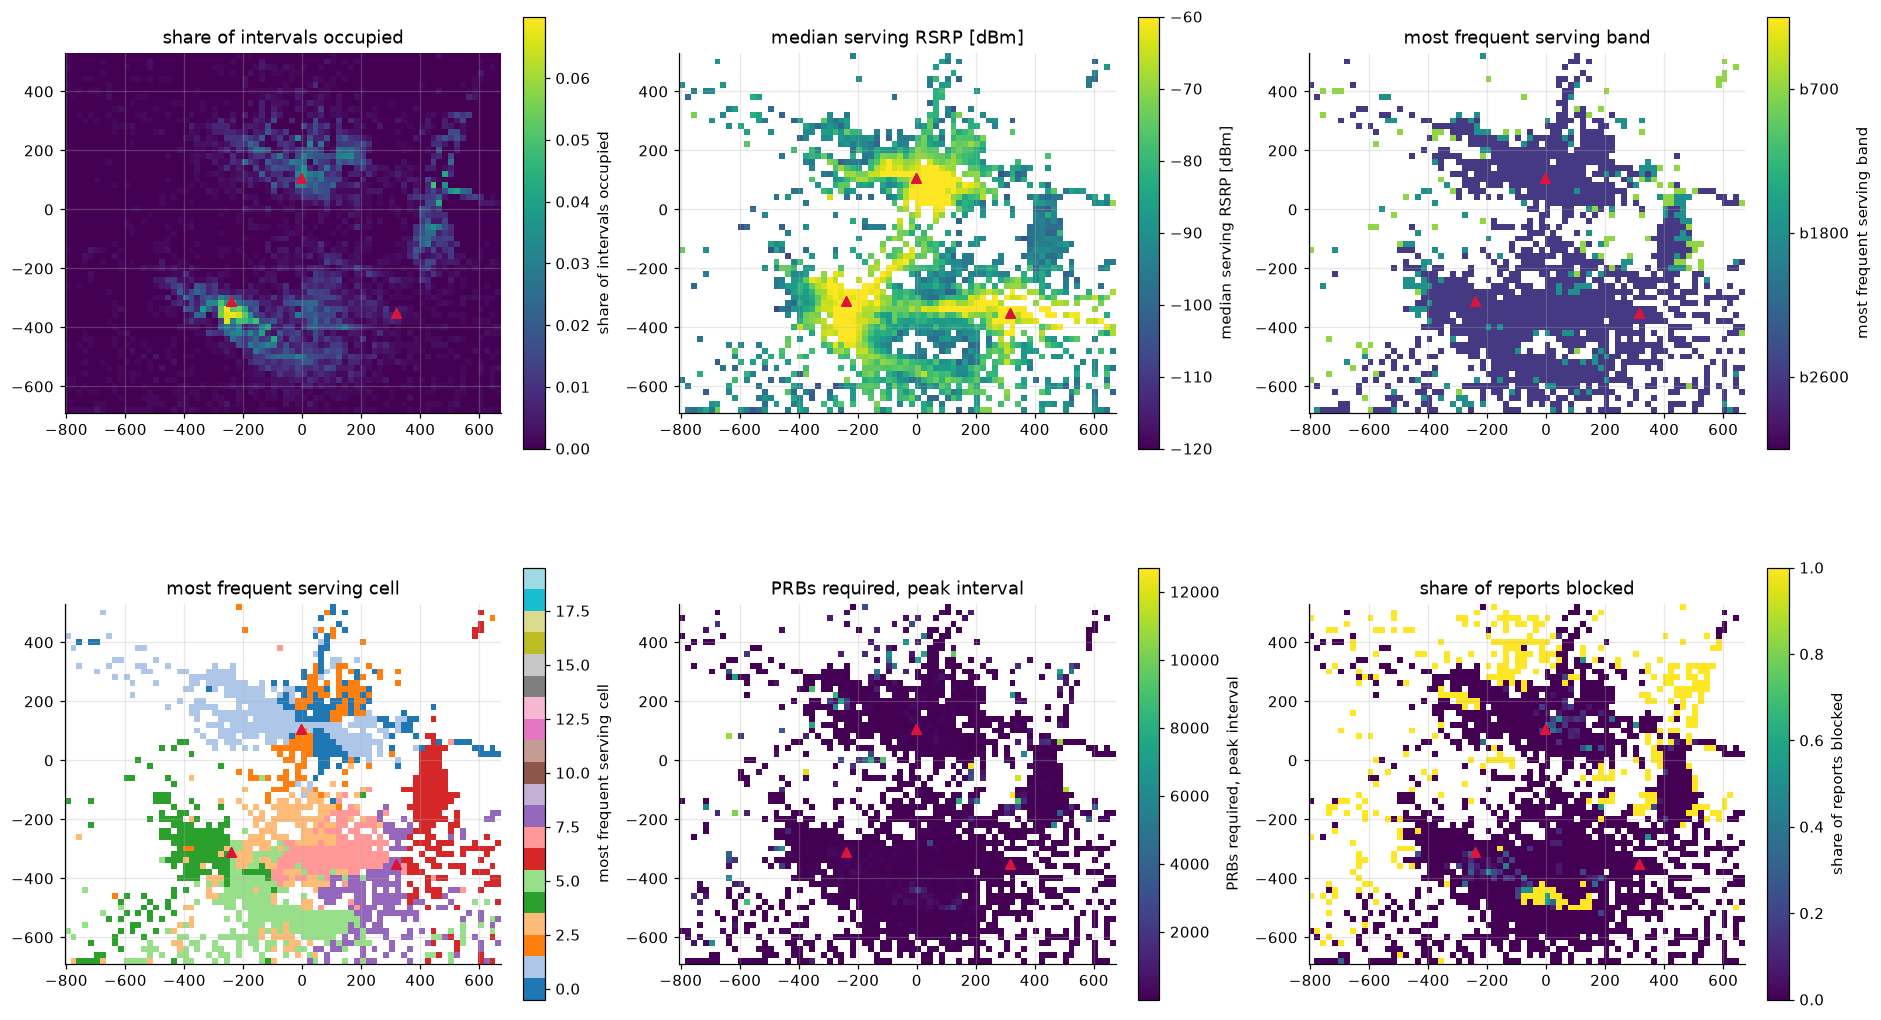

In [42]:
n_intervals = int(manifest["time"]["n_intervals"])
occupied = mdt.drop_duplicates(["t_index", "tile_row", "tile_col"])
occupancy = np.zeros((n_rows, n_cols))
np.add.at(
    occupancy, (occupied["tile_row"].to_numpy(), occupied["tile_col"].to_numpy()), 1.0 / n_intervals
)


def tile_raster(frame, column, how):
    """Reduce ``column`` per tile into an ``[n_rows, n_cols]`` raster, NaN where empty."""
    reduced = frame.groupby(["tile_row", "tile_col"])[column].agg(how)
    raster_values = np.full((n_rows, n_cols), np.nan)
    raster_values[reduced.index.get_level_values(0), reduced.index.get_level_values(1)] = (
        reduced.to_numpy()
    )
    return raster_values


with_rsrp = served.assign(serving_rsrp_dbm=serving_rsrp, blocked=(served["band"] < 0).astype(float))
median_serving = tile_raster(with_rsrp, "serving_rsrp_dbm", "median")
blocked_share = tile_raster(with_rsrp, "blocked", "mean")
serving_band_mode = tile_raster(served[has_cell], "band", lambda s: s.mode().iloc[0])
serving_cell_mode = tile_raster(served[has_cell], "tx", lambda s: s.mode().iloc[0])

panels = (
    (occupancy, "share of intervals occupied", {}),
    (median_serving, "median serving RSRP [dBm]", {"vmin": -120.0, "vmax": -60.0}),
    (
        serving_band_mode,
        "most frequent serving band",
        {"cmap": "viridis", "vmin": -0.5, "vmax": len(bands) - 0.5},
    ),
    (
        serving_cell_mode,
        "most frequent serving cell",
        {"cmap": "tab20", "vmin": -0.5, "vmax": 19.5},
    ),
    (np.where(peak_prb > 0, peak_prb, np.nan), "PRBs required, peak interval", {}),
    (blocked_share, "share of reports blocked", {"vmin": 0.0, "vmax": 1.0}),
)
figure, axes = plt.subplots(2, 3, figsize=(17.0, 10.0), constrained_layout=True)
for axis, (image_values, label, limits) in zip(np.ravel(axes), panels):
    image = axis.imshow(image_values, origin="lower", extent=extent, aspect="equal", **limits)
    colorbar = figure.colorbar(image, ax=axis, label=label, shrink=0.8)
    if label == "most frequent serving band":
        colorbar.set_ticks(range(len(bands)), labels=bands)
    axis.scatter(cells["x"], cells["y"], marker="^", s=35, color="crimson", zorder=3)
    axis.set_title(label)
save_fig(figure, "spatial_serving_and_demand")
plt.show()

In [43]:
by_prb = maps.coverage_table(rsrp.astype(float), peak_prb, cfg).set_index("coverage")
coverage_by_demand = pd.DataFrame(
    {
        "tiles": by_prb["tiles"],
        "tile_share": by_prb["tile_share"],
        "peak_prb_share": by_prb["demand_share"],
    }
)
save_table(coverage_by_demand.reset_index(), "coverage_class_by_demand")
coverage_by_demand

,tiles,tile_share,peak_prb_share
coverage,,,
hole,1291,0.285999,0.000000
weak,725,0.160611,0.806086
good,2498,0.553389,0.193914


## 9. Data Quality Issues and Candidate Hard Constraints

The output of this section feeds directly into notebook 02.

For every filter proposed, the **external source** of the bound is written down.
Where no source can be named, it is a statistical threshold and belongs in `02x`,
fitted on train only.

The KPI thresholds below *classify* a tile; they do not filter a row. They are
listed here because notebook 02 must not silently drop the tiles they describe.

In [44]:
# The grid covers the whole scene since the region of interest was dropped, so
# the grid extent is the bound a UE position must respect.
max_x = grid_meta["origin_x"] + grid_meta["n_cols"] * grid_meta["tile_size_m"]
max_y = grid_meta["origin_y"] + grid_meta["n_rows"] * grid_meta["tile_size_m"]
values = mdt[measurement_columns].to_numpy()
finite = values[np.isfinite(values)]

constraint_violations = pd.DataFrame(
    [
        (
            "ue.z == ue.height_m",
            "configs/simulation.yaml simulation.ue.height_m",
            int((ue["z"] != float(cfg.simulation.ue.height_m)).sum()),
        ),
        (
            "0 <= tile_row < n_rows",
            "manifest grid",
            int(((ue["tile_row"] < 0) | (ue["tile_row"] >= grid_meta["n_rows"])).sum()),
        ),
        (
            "0 <= tile_col < n_cols",
            "manifest grid",
            int(((ue["tile_col"] < 0) | (ue["tile_col"] >= grid_meta["n_cols"])).sum()),
        ),
        (
            "x within the grid extent",
            "manifest grid",
            int(((ue["x"] < grid_meta["origin_x"]) | (ue["x"] > max_x)).sum()),
        ),
        (
            "y within the grid extent",
            "manifest grid",
            int(((ue["y"] < grid_meta["origin_y"]) | (ue["y"] > max_y)).sum()),
        ),
        (
            "reported RSRP <= the transmit reference-signal power",
            "configs/simulation.yaml simulation.antenna.power_rs",
            int((finite > float(cfg.simulation.antenna.power_rs)).sum()),
        ),
        (
            "reported RSRP <= -120 dBm (hole threshold)",
            "docs/adr/0001-four-kpis-and-weighted-score.md",
            int((finite <= -120.0).sum()),
        ),
        (
            "-120 < reported RSRP <= -90 dBm (weak threshold)",
            "docs/adr/0001-four-kpis-and-weighted-score.md",
            int(((finite > -120.0) & (finite <= -90.0)).sum()),
        ),
    ],
    columns=["rule", "source", "records affected"],
)
save_table(constraint_violations, "constraint_violations")
constraint_violations

,rule,source,records affected
0,ue.z == ue.height_m,configs/simulation.yaml simulation.ue.height_m,0
1,0 <= tile_row < n_rows,manifest grid,0
2,0 <= tile_col < n_cols,manifest grid,0
3,x within the grid extent,manifest grid,0
4,y within the grid extent,manifest grid,0
5,reported RSRP <= the transmit reference-signal...,configs/simulation.yaml simulation.antenna.pow...,0
6,reported RSRP <= -120 dBm (hole threshold),docs/adr/0001-four-kpis-and-weighted-score.md,27716
7,-120 < reported RSRP <= -90 dBm (weak threshold),docs/adr/0001-four-kpis-and-weighted-score.md,39329


In [45]:
coverage = np.where(np.isfinite(best_server), best_server, -np.inf)

coverage_rate_by_band = pd.DataFrame(
    {
        "hole_rate": (coverage <= -120.0).mean(axis=(1, 2)),
        "weak_rate": ((coverage > -120.0) & (coverage <= -90.0)).mean(axis=(1, 2)),
        "good_rate": (coverage > -90.0).mean(axis=(1, 2)),
    },
    index=bands,
)
save_table(coverage_rate_by_band.rename_axis("band").reset_index(), "coverage_rate_by_band")
coverage_rate_by_band

,hole_rate,weak_rate,good_rate
b2600,0.380815,0.261409,0.357776
b1800,0.368631,0.226407,0.404962
b700,0.309039,0.147098,0.543864


### MDT Anomalies

In [46]:
reported_values = values[np.isfinite(values)]

anomalies = pd.DataFrame(
    [
        (
            "reported RSRP < -156 dBm",
            "NR SS-RSRP report range lower bound, TS 38.133 10.1.6 (to verify)",
            int((reported_values < -156.0).sum()),
            reported_values.size,
        ),
        (
            "reported RSRP > power_rs",
            "configs/simulation.yaml simulation.antenna.power_rs",
            int((reported_values > float(cfg.simulation.antenna.power_rs)).sum()),
            reported_values.size,
        ),
        (
            "duplicate (t_index, x, y)",
            "one UE per position per interval",
            int(mdt.duplicated(subset=["t_index", "x", "y"]).sum()),
            len(mdt),
        ),
        ("UEs dropped for hearing nothing", "src/simulation/mdt.py", len(ue) - len(mdt), len(ue)),
        (
            "reports blocked by the PRB limits",
            "kpi.capacity (placeholder values)",
            int((served["band"] < 0).sum()),
            len(mdt),
        ),
    ],
    columns=["check", "reference", "records", "out_of"],
)
anomalies["share"] = anomalies["records"] / anomalies["out_of"]
save_table(anomalies, "mdt_anomalies")
anomalies

,check,reference,records,out_of,share
0,reported RSRP < -156 dBm,"NR SS-RSRP report range lower bound, TS 38.133...",2022,113523,0.017811
1,reported RSRP > power_rs,configs/simulation.yaml simulation.antenna.pow...,0,113523,0.000000
2,"duplicate (t_index, x, y)",one UE per position per interval,0,8874,0.000000
3,UEs dropped for hearing nothing,src/simulation/mdt.py,1192,10066,0.118418
4,reports blocked by the PRB limits,kpi.capacity (placeholder values),1304,8874,0.146946


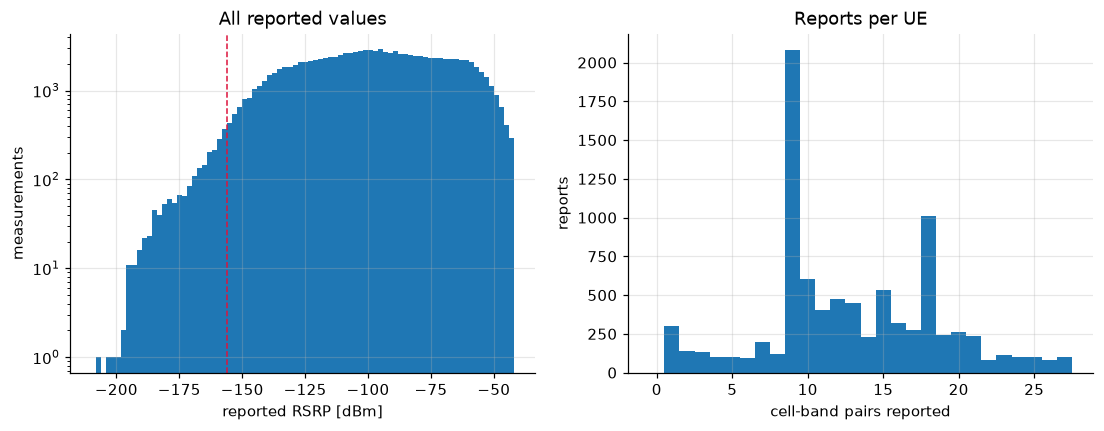

In [47]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
axes[0].hist(reported_values, bins=np.arange(-210.0, -40.0, 2.0))
axes[0].axvline(-156.0, color="crimson", ls="--", lw=1.0)
axes[0].set(
    xlabel="reported RSRP [dBm]", ylabel="measurements", yscale="log", title="All reported values"
)
axes[1].hist(reports_per_ue, bins=np.arange(reports_per_ue.max() + 2) - 0.5)
axes[1].set(xlabel="cell-band pairs reported", ylabel="reports", title="Reports per UE")
save_fig(figure, "mdt_low_tail_and_report_count")
plt.show()

### Within-Tile Spread

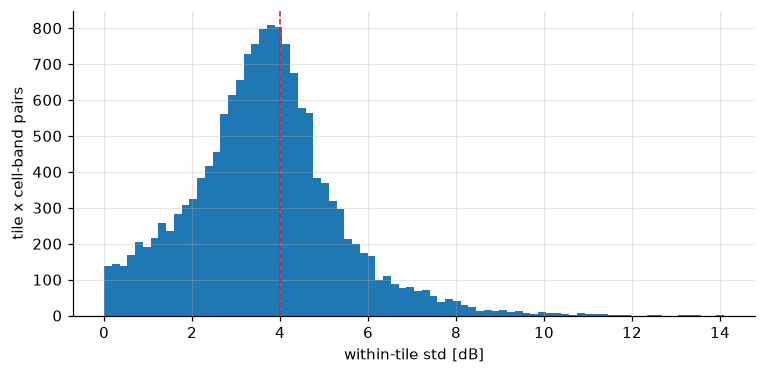

,within-tile std of reported RSRP [dB]
count,15258.000000
mean,3.641896
std,1.688863
min,0.000000
25%,2.626015
50%,3.633565
75%,4.526660
max,14.091931
configured sigma,4.000000


In [48]:
# Every UE in a tile reads the same clean value, so spread within a tile is the
# measurement noise alone.
within_tile_std = mdt.groupby(["tile_row", "tile_col"])[measurement_columns].std().stack()
within_tile_table = within_tile_std.describe().to_frame("within-tile std of reported RSRP [dB]")
within_tile_table.loc["configured sigma"] = float(cfg.simulation.mdt.rsrp_noise_sigma_db)
save_table(within_tile_table.rename_axis("statistic").reset_index(), "within_tile_spread")

figure, axis = plt.subplots(figsize=(8.0, 3.6))
axis.hist(within_tile_std, bins=80)
axis.axvline(float(cfg.simulation.mdt.rsrp_noise_sigma_db), color="crimson", ls="--", lw=1.0)
axis.set(xlabel="within-tile std [dB]", ylabel="tile x cell-band pairs")
save_fig(figure, "within_tile_spread")
plt.show()
within_tile_table

## 10. Findings — What 02 and 02x Must Do

**Blocker.** One scenario is on disk. The intended between-scenario split cannot
be made until `task simulation` has been run for several seeds. Until then any
split is within-scenario and optimistic.

**For notebook 02 (deterministic, model-agnostic):**
- Split unit: `scenario_id` from the manifest. Within a scenario, `t_index` is
  the coarsest honest fallback — never a random row split, because UEs repeat
  tiles and every UE in a tile reads the same radio-map values.
- Join key: `ue_positions.csv` and `mdt.csv` are **not** row-aligned; join on
  `(t_index, x, y)` or regenerate, never on row order.
- Empty `rsrp_*` in the MDT means *no path* and must not be read as
  zero. Carry an explicit "reported" indicator alongside every value.
- Hard constraints: the rows in section 10 whose source is the manifest or the
  config. The KPI thresholds classify tiles and must not be used to drop rows.
- Drop nothing on the strength of the −120/−90 dBm thresholds: holes are the
  measurement, not the defect.

**For the `02x` notebooks (learned from train only):**
- Missing values: the measurement columns are empty only where no ray arrived.
- Scaling: RSRP is already in dB and roughly linear in log-distance; centring per
  band is likely enough.
- Feature ideas: distance and bearing to each cell, the cell's tilt on that
  band, and local built volume from the raster.

**Open questions:**
- How many scenarios are needed before a between-scenario split is stable?
